# Oil Markets & Geopolitics: Exploratory Data Analysis (2010–2026)

---

## Notebook Overview

This notebook presents a comprehensive **Exploratory Data Analysis (EDA)** of daily oil market data enriched with geopolitical event annotations and engineered financial features, spanning from **2010 to 2026**.

The central research question is:

> **How do geopolitical events shape oil price dynamics, volatility regimes, and market uncertainty?**

---

## Key Concepts

| Term | Description |
|------|-------------|
| **Brent Crude** | The global benchmark for oil prices, extracted from the North Sea. Used for pricing ~2/3 of globally traded oil. |
| **WTI (West Texas Intermediate)** | The US benchmark crude oil. Generally slightly cheaper than Brent. |
| **GPR Index** | The *Geopolitical Risk Index* (Caldara & Iacoviello) — a text-based measure of geopolitical risk constructed from news articles. Higher = more risk. |
| **DXY Index** | The US Dollar Index — measures USD strength against a basket of major currencies. Inversely correlated with oil prices (oil is USD-denominated). |
| **VIX** | The CBOE Volatility Index — the market's "fear gauge." Measures implied volatility of S&P 500 options. |
| **Event Flag** | Binary indicator (0/1) marking days with significant geopolitical events. |

---

## Dataset Columns

| Column | Description |
|--------|-------------|
| `date` | Trading date |
| `brent_price`, `wti_price` | Daily closing prices (USD/barrel) |
| `dxy_index` | US Dollar Index |
| `vix` | VIX fear index |
| `gpr_index` | Geopolitical Risk Index |
| `brent_return`, `wti_return` | Daily log returns |
| `brent_lag_1/3/7`, `wti_lag_1/3/7` | Lagged prices (1, 3, 7 days) |
| `brent_volatility_7d/30d`, `wti_volatility_7d/30d` | Rolling volatility |
| `brent_wti_spread` | Price spread between Brent and WTI |
| `event_flag` | 1 = geopolitical event occurred |
| `event_type` | Category (war, sanctions, attack, etc.) |
| `event_description` | Text description of the event |
| `event_severity` | Severity score of the event |


---
## 1. Imports & Display Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Styling ────────────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

BRENT_COLOR  = '#1f77b4'
WTI_COLOR    = '#d62728'
GPR_COLOR    = '#e377c2'
VIX_COLOR    = '#ff7f0e'
SPREAD_COLOR = '#2ca02c'
EVENT_COLOR  = '#9467bd'

print(" Libraries loaded successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   seaborn : {sns.__version__}")


 Libraries loaded successfully.
   pandas  : 2.3.3
   numpy   : 2.0.2
   seaborn : 0.13.2


---
## 2. Data Loading & Initial Inspection

We begin by loading the dataset, parsing the `date` column, and conducting a first structural inspection — shape, dtypes, and a preview of the first few rows.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/kavyadhyani/global-oil-prices-and-geopolitical-events/oil_geopolitics_dataset_2010_2026.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range    : {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"Trading days  : {df['date'].nunique():,}")


Dataset shape : 4,047 rows × 23 columns
Date range    : 2010-02-17  →  2026-03-12
Trading days  : 4,047


In [3]:
df.head(8)


,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,...,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag
0,2010-02-17,76.269997,77.330002,80.379997,21.719999,80.725357,0.007796,0.004155,75.680000,73.050003,...,71.190002,0.014461,0.019679,0.016977,0.019280,-1.060005,none,none,0.0,0
1,2010-02-18,77.779999,79.059998,80.400002,20.629999,80.725357,0.019798,0.022372,76.269997,72.900002,...,71.889999,0.014387,0.020019,0.017366,0.019756,-1.279999,none,none,0.0,0
2,2010-02-19,78.190002,79.809998,80.639999,20.020000,80.725357,0.005271,0.009486,77.779999,75.680000,...,73.750000,0.013342,0.019796,0.016553,0.019559,-1.619995,none,none,0.0,0
3,2010-02-22,78.610001,80.160004,80.510002,19.940001,80.725357,0.005372,0.004385,78.190002,76.269997,...,74.519997,0.013366,0.019823,0.016772,0.019561,-1.550003,none,none,0.0,0
4,2010-02-23,77.250000,78.860001,80.849998,21.370001,80.725357,-0.017301,-0.016218,78.610001,77.779999,...,75.279999,0.017334,0.020045,0.019608,0.019756,-1.610001,none,none,0.0,0
5,2010-02-24,78.089996,80.000000,80.849998,20.270000,80.725357,0.010874,0.014456,77.250000,78.190002,...,74.129997,0.016745,0.020160,0.017081,0.019965,-1.910004,none,none,0.0,0
6,2010-02-25,76.290001,78.169998,80.790001,20.100000,80.725357,-0.023050,-0.022875,78.089996,78.610001,...,77.010002,0.015531,0.020246,0.016262,0.020034,-1.879997,none,none,0.0,0
7,2010-02-26,77.589996,79.660004,80.360001,19.500000,80.725357,0.017040,0.019061,76.290001,77.250000,...,77.330002,0.016541,0.020390,0.017483,0.020195,-2.070007,none,none,0.0,0


In [4]:
df.tail(5)


,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,...,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag
4042,2026-03-06,92.690002,90.900002,98.989998,29.49,130.887665,0.085236,0.122084,85.410004,81.400002,...,65.419998,0.033662,0.029489,0.045250,0.034029,1.790001,none,none,0.0,0
4043,2026-03-09,98.959999,94.769997,99.180000,25.50,130.887665,0.067645,0.042574,92.690002,81.400002,...,65.209999,0.029502,0.031034,0.039384,0.034316,4.190002,blockade,Closure of Strait of Hormuz shipping lane,10.0,1
4044,2026-03-10,87.800003,83.449997,98.830002,24.93,130.887665,-0.112773,-0.119447,98.959999,85.410004,...,67.019997,0.068590,0.038639,0.077506,0.042092,4.350006,none,none,0.0,0
4045,2026-03-11,91.980003,87.250000,99.230003,24.23,130.887665,0.047608,0.045536,87.800003,92.690002,...,71.230003,0.066619,0.039074,0.076723,0.042435,4.730003,none,none,0.0,0
4046,2026-03-12,95.760002,94.309998,99.463997,24.23,130.887665,0.041096,0.080917,91.980003,98.959999,...,74.559998,0.066346,0.039457,0.078875,0.044257,1.450005,none,none,0.0,0


In [5]:
print("\n Column Data Types\n" + "─"*40)
print(df.dtypes.to_string())



 Column Data Types
────────────────────────────────────────
date                    datetime64[ns]
brent_price                    float64
wti_price                      float64
dxy_index                      float64
vix                            float64
gpr_index                      float64
brent_return                   float64
wti_return                     float64
brent_lag_1                    float64
brent_lag_3                    float64
brent_lag_7                    float64
wti_lag_1                      float64
wti_lag_3                      float64
wti_lag_7                      float64
brent_volatility_7d            float64
brent_volatility_30d           float64
wti_volatility_7d              float64
wti_volatility_30d             float64
brent_wti_spread               float64
event_type                      object
event_description               object
event_severity                 float64
event_flag                       int64


In [6]:
print("\n Column List")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")



 Column List
   1. date
   2. brent_price
   3. wti_price
   4. dxy_index
   5. vix
   6. gpr_index
   7. brent_return
   8. wti_return
   9. brent_lag_1
  10. brent_lag_3
  11. brent_lag_7
  12. wti_lag_1
  13. wti_lag_3
  14. wti_lag_7
  15. brent_volatility_7d
  16. brent_volatility_30d
  17. wti_volatility_7d
  18. wti_volatility_30d
  19. brent_wti_spread
  20. event_type
  21. event_description
  22. event_severity
  23. event_flag


---
## 3. Data Quality Check

Before diving into analysis, we must validate the data for:
- **Missing values** — which columns have NaNs and why?
- **Duplicate rows** — are any trading dates repeated?
- **Logical bounds** — do price/volatility values fall within expected ranges?

> **Note on NaNs:** Lagged and rolling volatility columns are expected to have NaN values at the start of the time series — these are *structural* NaNs created by the rolling window calculations, not data errors.


In [7]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(" Missing Values Summary")
print("─" * 40)
if missing_df.empty:
    print("   No missing values found!")
else:
    print(missing_df.to_string())


 Missing Values Summary
────────────────────────────────────────
   No missing values found!


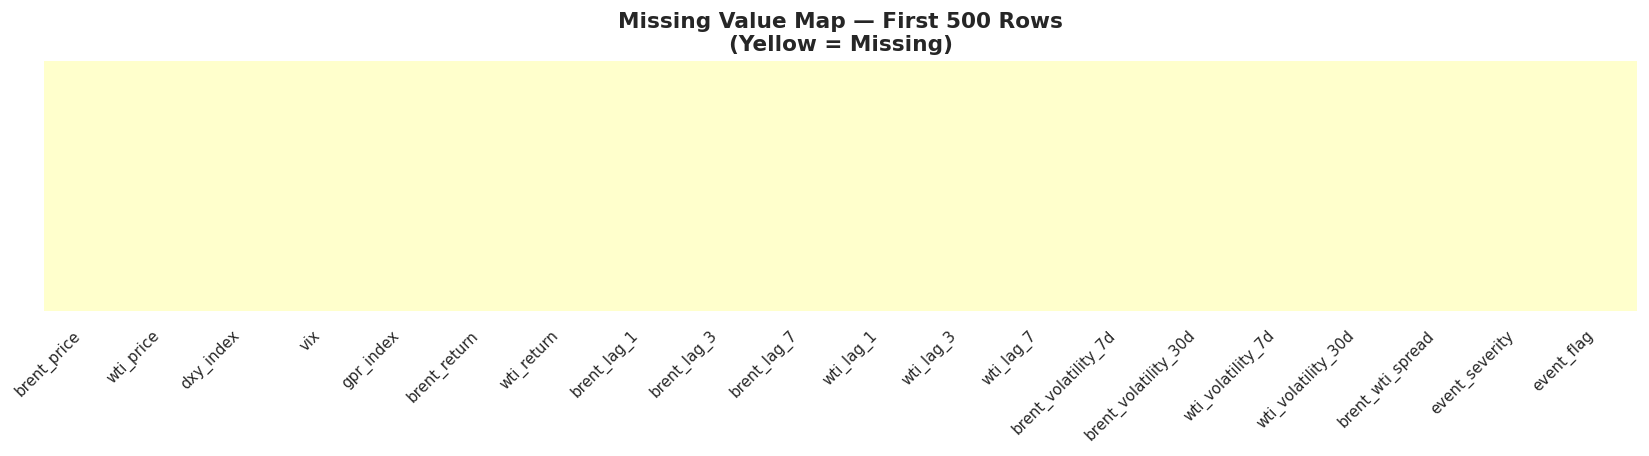

ℹ️  Structural NaNs in lag/volatility columns are expected at the series start.


In [8]:
# Visualise missing values as a heatmap (sample of first 500 rows for clarity)
fig, ax = plt.subplots(figsize=(14, 4))
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
sns.heatmap(df[numeric_cols].head(500).isnull(), cbar=False,
            cmap='YlOrRd', ax=ax, yticklabels=False)
ax.set_title('Missing Value Map — First 500 Rows\n(Yellow = Missing)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()
print("ℹ️  Structural NaNs in lag/volatility columns are expected at the series start.")


In [9]:
# Duplicate check
dupes = df.duplicated(subset='date').sum()
print(f" Duplicate dates: {dupes}")

# Numeric range check
price_cols = ['brent_price', 'wti_price']
print("\n Price Range Validation")
print("─" * 40)
for col in price_cols:
    print(f"  {col}: min={df[col].min():.2f}  max={df[col].max():.2f}  negatives={( df[col] < 0).sum()}")

vol_cols = [c for c in df.columns if 'volatility' in c]
print("\n Volatility Range Validation")
print("─" * 40)
for col in vol_cols:
    print(f"  {col}: min={df[col].min():.4f}  max={df[col].max():.4f}")


 Duplicate dates: 0

 Price Range Validation
────────────────────────────────────────
  brent_price: min=19.33  max=127.98  negatives=0
  wti_price: min=-37.63  max=123.70  negatives=1

 Volatility Range Validation
────────────────────────────────────────
  brent_volatility_7d: min=0.0025  max=0.1149
  brent_volatility_30d: min=0.0058  max=0.0886
  wti_volatility_7d: min=0.0022  max=1.2304
  wti_volatility_30d: min=0.0070  max=0.6205


---
## 4. Descriptive Statistics

Summary statistics help us understand the **central tendency, spread, and extremes** of each variable before deeper analysis.

Key things to look for:
- **Prices**: typical range and historical extremes (e.g., COVID crash, Russia-Ukraine spike)
- **Returns**: near-zero mean with fat tails (typical for financial returns)
- **GPR Index**: baseline vs. spikes during crises
- **VIX**: normal market vs. crisis periods


In [10]:
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)

stats = df[numeric_cols].describe().T
stats['skewness'] = df[numeric_cols].skew()
stats['kurtosis'] = df[numeric_cols].kurt()
stats.round(4)


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
brent_price,4047.0000,77.6239,23.5293,19.3300,60.7850,75.1700,98.1550,127.9800,0.1319,-0.9002
wti_price,4047.0000,71.4175,20.7773,-37.6300,54.3400,71.1200,88.1800,123.7000,-0.0414,-0.6530
dxy_index,4047.0000,92.9090,9.2855,72.9300,82.7350,95.3100,99.1800,114.1100,-0.3463,-0.9577
vix,4047.0000,18.3932,6.8538,9.1400,13.7750,16.6500,21.0100,82.6900,2.4077,11.1552
gpr_index,4047.0000,102.5964,31.5592,58.4208,81.3896,93.5213,116.7163,318.9549,2.4409,11.8195
brent_return,4047.0000,0.0003,0.0224,-0.2440,-0.0097,0.0005,0.0110,0.2102,-0.3874,12.8476
wti_return,4047.0000,-0.0005,0.0581,-3.0597,-0.0115,0.0009,0.0124,0.3766,-38.5617,1957.3586
brent_lag_1,4047.0000,77.6190,23.5276,19.3300,60.7850,75.1700,98.1550,127.9800,0.1324,-0.8995
brent_lag_3,4047.0000,77.6106,23.5262,19.3300,60.7850,75.1700,98.1550,127.9800,0.1334,-0.8989
brent_lag_7,4047.0000,77.5923,23.5231,19.3300,60.7850,75.1300,98.1350,127.9800,0.1355,-0.8976


In [11]:
# Quick highlights
print(" Key Descriptive Highlights")
print("─" * 50)
print(f"  Brent avg price     : ${df['brent_price'].mean():.2f}/barrel")
print(f"  WTI avg price       : ${df['wti_price'].mean():.2f}/barrel")
print(f"  Brent all-time high : ${df['brent_price'].max():.2f}  ({df.loc[df['brent_price'].idxmax(), 'date'].date()})")
print(f"  WTI all-time high   : ${df['wti_price'].max():.2f}  ({df.loc[df['wti_price'].idxmax(), 'date'].date()})")
print(f"  Brent all-time low  : ${df['brent_price'].min():.2f}  ({df.loc[df['brent_price'].idxmin(), 'date'].date()})")
print(f"  WTI all-time low    : ${df['wti_price'].min():.2f}  ({df.loc[df['wti_price'].idxmin(), 'date'].date()})")
print(f"  Avg GPR index       : {df['gpr_index'].mean():.1f}")
print(f"  Max GPR index       : {df['gpr_index'].max():.1f}  ({df.loc[df['gpr_index'].idxmax(), 'date'].date()})")
print(f"  Avg VIX             : {df['vix'].mean():.1f}")
print(f"  Max VIX             : {df['vix'].max():.1f}  ({df.loc[df['vix'].idxmax(), 'date'].date()})")
print(f"  Geopolitical events : {df['event_flag'].sum():,} flagged trading days")


 Key Descriptive Highlights
──────────────────────────────────────────────────
  Brent avg price     : $77.62/barrel
  WTI avg price       : $71.42/barrel
  Brent all-time high : $127.98  (2022-03-08)
  WTI all-time high   : $123.70  (2022-03-08)
  Brent all-time low  : $19.33  (2020-04-21)
  WTI all-time low    : $-37.63  (2020-04-20)
  Avg GPR index       : 102.6
  Max GPR index       : 319.0  (2022-03-01)
  Avg VIX             : 18.4
  Max VIX             : 82.7  (2020-03-16)
  Geopolitical events : 25 flagged trading days


---
## 5. Time Series Overview

We plot the four core market indicators across the full 2010–2026 window. This gives us an immediate visual sense of:

- **Major price cycles**: the 2014–16 oil glut, the 2020 COVID collapse, the 2022 Russia-Ukraine shock
- **GPR spikes**: sharp, episodic jumps around geopolitical events
- **VIX regime changes**: periods of elevated systemic fear

We annotate major macro events directly on the charts for context.


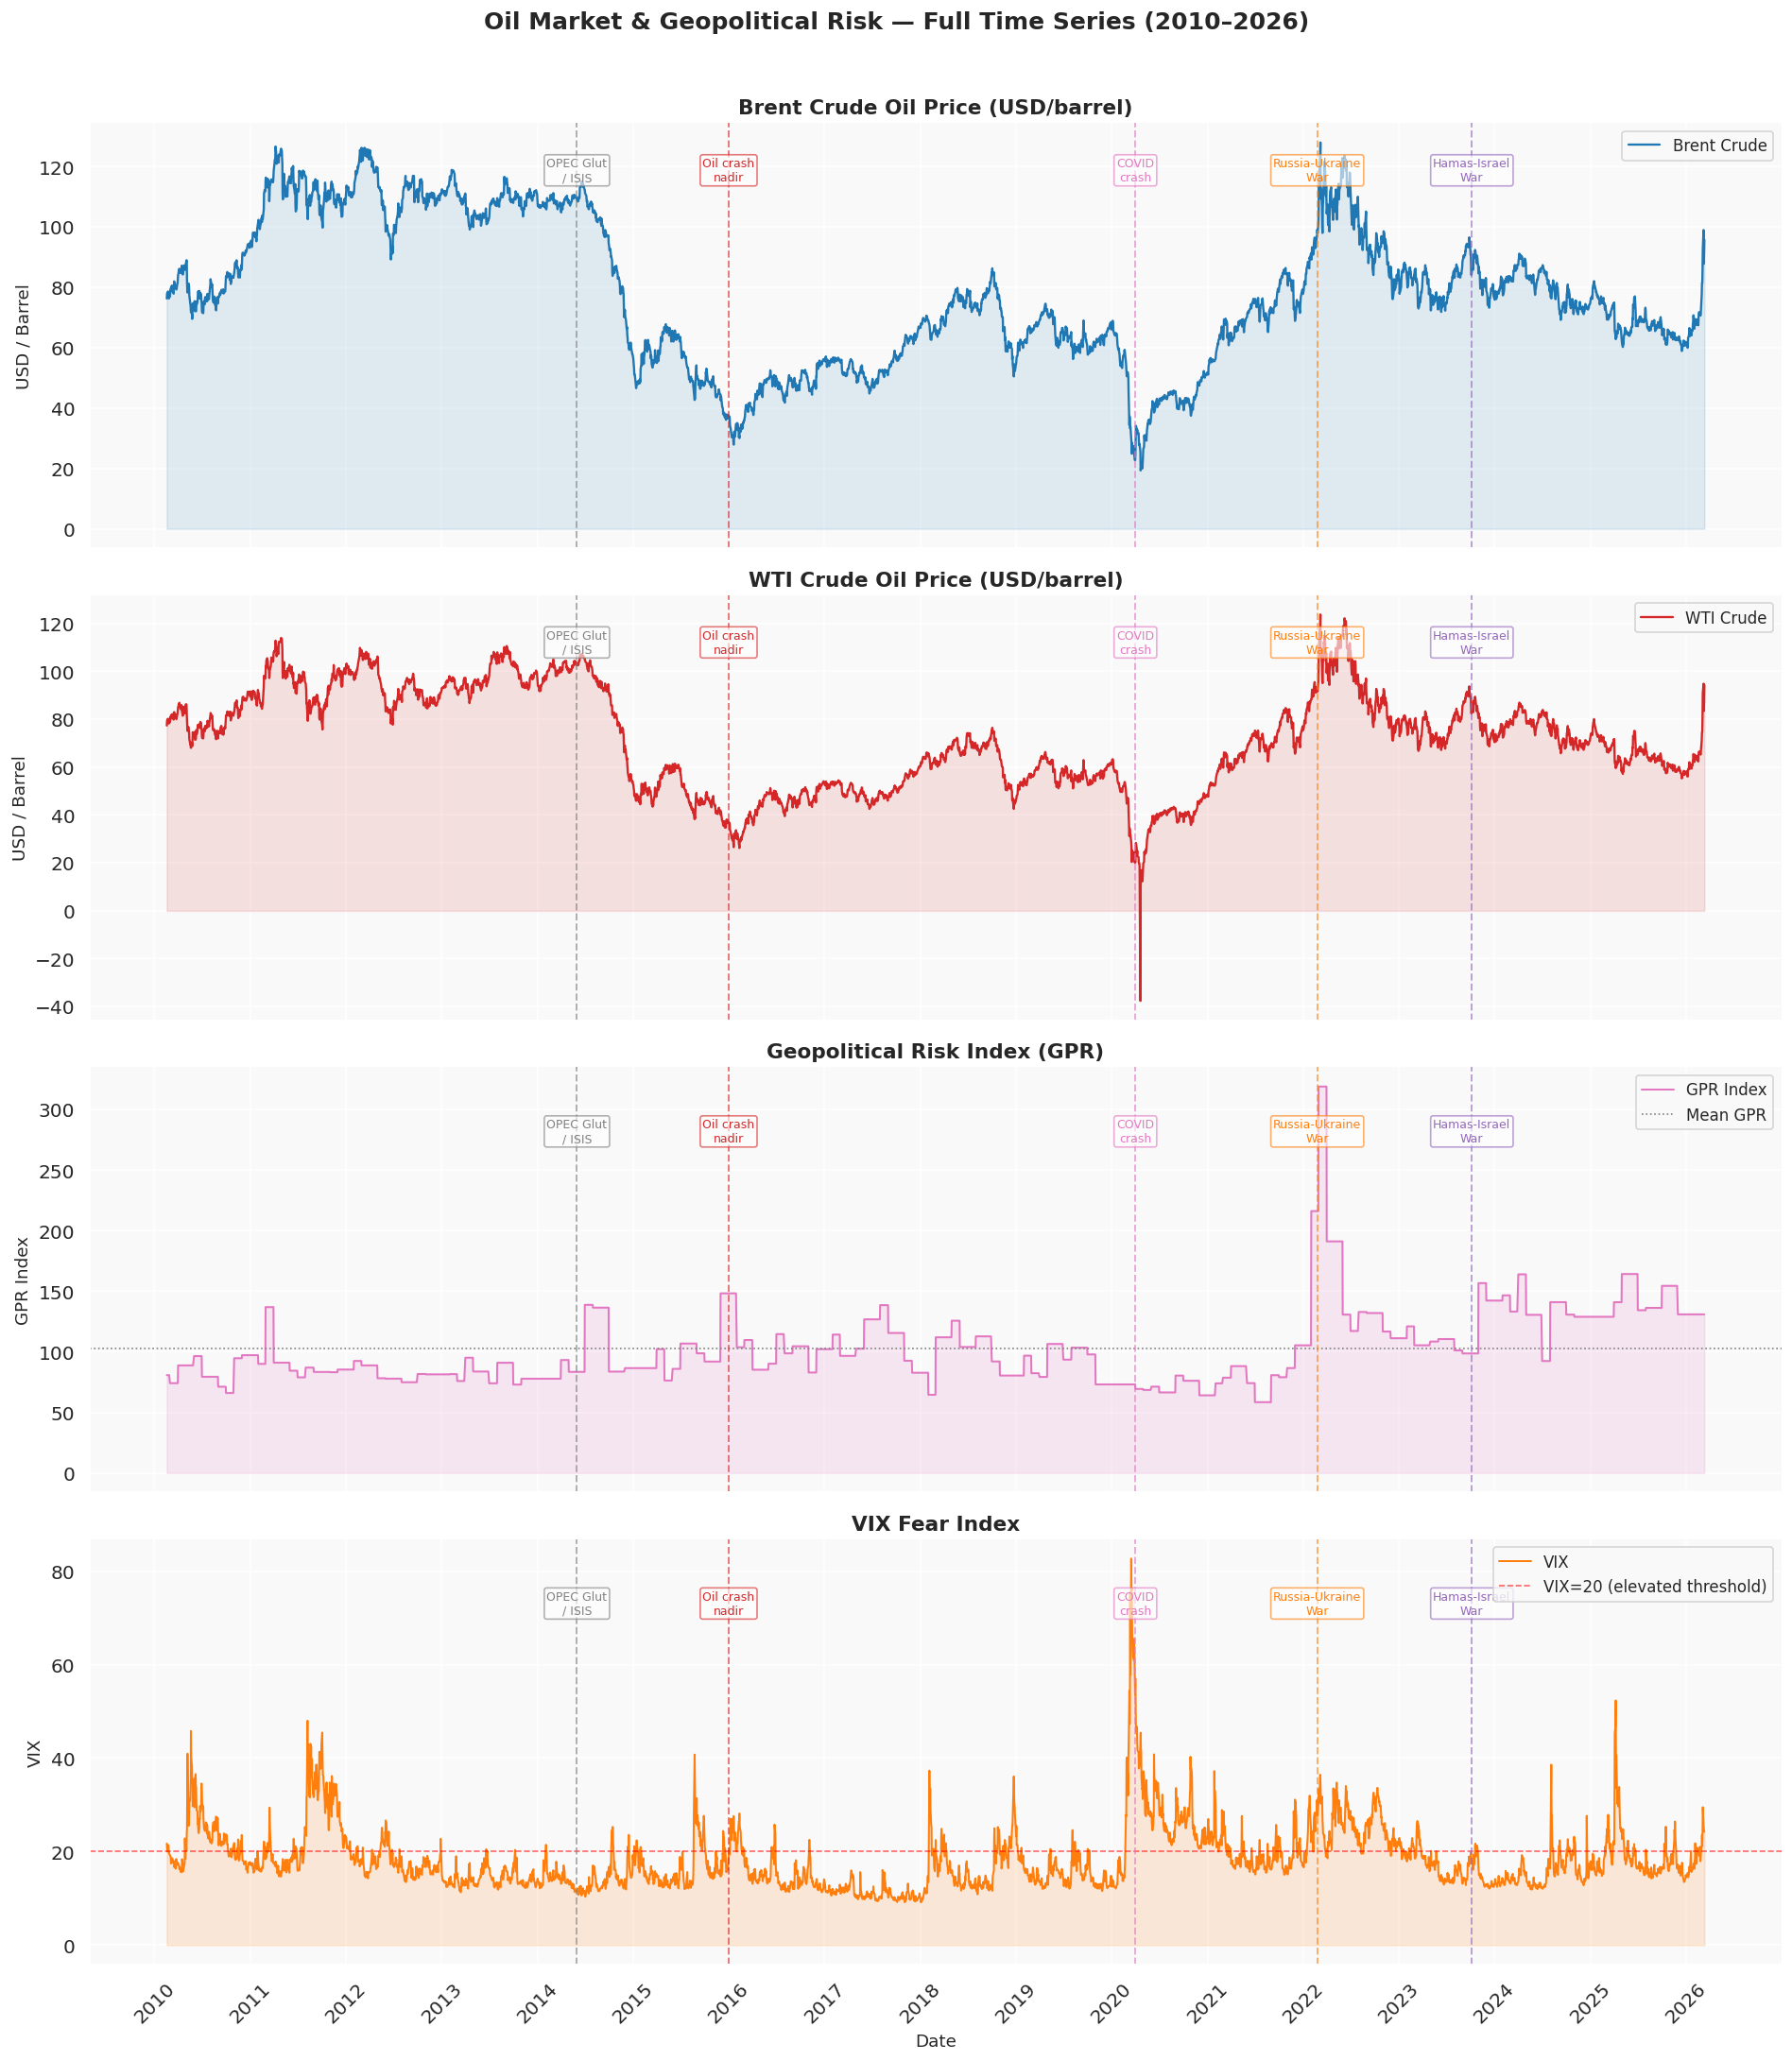

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)

# ── Common event annotations ───────────────────────────────────────────────────
annotations = {
    '2014-06-01': ('OPEC Glut\n/ ISIS', 'gray'),
    '2016-01-01': ('Oil crash\nnadir',  '#d62728'),
    '2020-04-01': ('COVID\ncrash',      '#e377c2'),
    '2022-02-24': ('Russia-Ukraine\nWar', '#ff7f0e'),
    '2023-10-07': ('Hamas-Israel\nWar',  '#9467bd'),
}

def add_events(ax, yloc_frac=0.92):
    ymin, ymax = ax.get_ylim()
    ypos = ymin + (ymax - ymin) * yloc_frac
    for date_str, (label, color) in annotations.items():
        try:
            xpos = pd.Timestamp(date_str)
            ax.axvline(xpos, color=color, lw=1.2, ls='--', alpha=0.6)
            ax.text(xpos, ypos, label, fontsize=7.5, color=color,
                    ha='center', va='top', rotation=0,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6, edgecolor=color))
        except Exception:
            pass

# ── 1. Brent Price ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df['date'], df['brent_price'], color=BRENT_COLOR, lw=1.4, label='Brent Crude')
ax.fill_between(df['date'], df['brent_price'], alpha=0.12, color=BRENT_COLOR)
ax.set_ylabel('USD / Barrel', fontsize=11)
ax.set_title('Brent Crude Oil Price (USD/barrel)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
add_events(ax)

# ── 2. WTI Price ───────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df['date'], df['wti_price'], color=WTI_COLOR, lw=1.4, label='WTI Crude')
ax.fill_between(df['date'], df['wti_price'], alpha=0.12, color=WTI_COLOR)
ax.set_ylabel('USD / Barrel', fontsize=11)
ax.set_title('WTI Crude Oil Price (USD/barrel)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
add_events(ax)

# ── 3. GPR Index ───────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(df['date'], df['gpr_index'], color=GPR_COLOR, lw=1.2, label='GPR Index')
ax.fill_between(df['date'], df['gpr_index'], alpha=0.15, color=GPR_COLOR)
ax.axhline(df['gpr_index'].mean(), color='gray', lw=1, ls=':', label='Mean GPR')
ax.set_ylabel('GPR Index', fontsize=11)
ax.set_title('Geopolitical Risk Index (GPR)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
add_events(ax, yloc_frac=0.88)

# ── 4. VIX ─────────────────────────────────────────────────────────────────────
ax = axes[3]
ax.plot(df['date'], df['vix'], color=VIX_COLOR, lw=1.2, label='VIX')
ax.fill_between(df['date'], df['vix'], alpha=0.15, color=VIX_COLOR)
ax.axhline(20, color='red', lw=1, ls='--', alpha=0.6, label='VIX=20 (elevated threshold)')
ax.set_ylabel('VIX', fontsize=11)
ax.set_title('VIX Fear Index', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
add_events(ax, yloc_frac=0.88)

# ── Format x-axis ──────────────────────────────────────────────────────────────
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45)

fig.suptitle('Oil Market & Geopolitical Risk — Full Time Series (2010–2026)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Key Time Series Observations

- **2011–2014**: Brent traded at a sustained premium above $100/barrel — driven by Arab Spring tensions and strong demand from emerging markets.
- **2014–2016**: A dramatic price collapse — OPEC's decision to maintain output flooded the market, causing Brent to fall from ~$115 to below $30.
- **2016–2019**: A gradual recovery, punctuated by US-Iran tensions (2018–19) and OPEC+ supply cuts.
- **2020 (COVID Crash)**: The most violent demand shock in history. WTI briefly went *negative* in April 2020 due to storage constraints. VIX spiked above 80.
- **2022 (Russia-Ukraine War)**: Supply shock caused Brent to surge past $130. GPR index recorded its highest sustained levels. VIX spiked sharply.
- **2023–2024**: Post-war volatility, Hamas-Israel conflict, and OPEC+ quota management kept markets reactive.


---
## 6. Brent vs. WTI Analysis

Brent and WTI prices are closely correlated — both reflect global crude oil supply/demand dynamics — but they diverge based on:
- **Regional supply shocks** (e.g., US shale boom widened the WTI discount)
- **Infrastructure constraints** (US pipeline/storage limitations)
- **Geopolitical proximity** (Middle East events affect Brent more directly)

The **Brent-WTI spread** is itself a market signal: a widening spread indicates a regional dislocation.


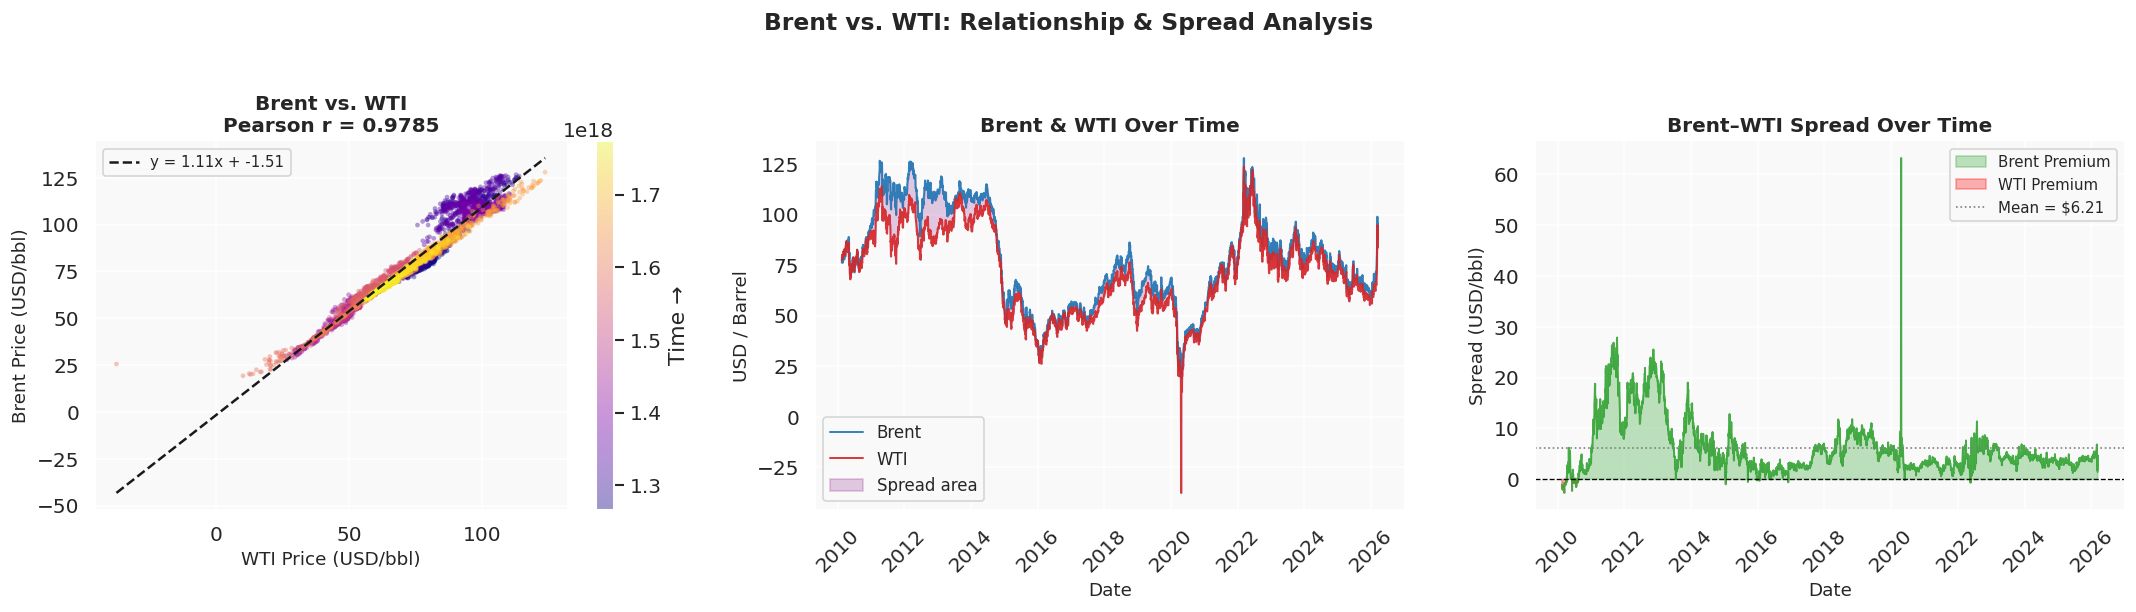

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Scatter Plot ────────────────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(df['wti_price'], df['brent_price'],
                c=df['date'].astype(np.int64), cmap='plasma',
                alpha=0.4, s=8, edgecolors='none')
m, b = np.polyfit(df['wti_price'].dropna(), df['brent_price'].dropna(), 1)
x_line = np.linspace(df['wti_price'].min(), df['wti_price'].max(), 200)
ax.plot(x_line, m * x_line + b, 'k--', lw=1.5, label=f'y = {m:.2f}x + {b:.2f}')
corr = df[['wti_price', 'brent_price']].corr().iloc[0, 1]
ax.set_xlabel('WTI Price (USD/bbl)', fontsize=11)
ax.set_ylabel('Brent Price (USD/bbl)', fontsize=11)
ax.set_title(f'Brent vs. WTI\nPearson r = {corr:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label='Time →')

# ── 2. Dual Time Series ────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df['date'], df['brent_price'], color=BRENT_COLOR, lw=1.2, label='Brent', alpha=0.9)
ax.plot(df['date'], df['wti_price'], color=WTI_COLOR, lw=1.2, label='WTI', alpha=0.9)
ax.fill_between(df['date'], df['brent_price'], df['wti_price'], alpha=0.2, color='purple', label='Spread area')
ax.set_title('Brent & WTI Over Time', fontsize=12, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('USD / Barrel', fontsize=11)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ── 3. Brent-WTI Spread ────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(df['date'], df['brent_wti_spread'], color=SPREAD_COLOR, lw=1.2, alpha=0.8)
ax.fill_between(df['date'], df['brent_wti_spread'], 0,
                where=(df['brent_wti_spread'] > 0), alpha=0.3, color=SPREAD_COLOR, label='Brent Premium')
ax.fill_between(df['date'], df['brent_wti_spread'], 0,
                where=(df['brent_wti_spread'] < 0), alpha=0.3, color='red', label='WTI Premium')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axhline(df['brent_wti_spread'].mean(), color='gray', lw=1, ls=':', label=f"Mean = ${df['brent_wti_spread'].mean():.2f}")
ax.set_title('Brent–WTI Spread Over Time', fontsize=12, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Spread (USD/bbl)', fontsize=11)
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

fig.suptitle('Brent vs. WTI: Relationship & Spread Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [14]:
print(" Brent–WTI Spread Statistics")
print("─" * 40)
spread_stats = df['brent_wti_spread'].describe()
print(spread_stats.round(4))
print(f"\n  Days Brent > WTI : {(df['brent_wti_spread'] > 0).sum():,} ({(df['brent_wti_spread'] > 0).mean()*100:.1f}%)")
print(f"  Days WTI > Brent : {(df['brent_wti_spread'] < 0).sum():,} ({(df['brent_wti_spread'] < 0).mean()*100:.1f}%)")
print(f"  Max Brent premium: ${df['brent_wti_spread'].max():.2f}  ({df.loc[df['brent_wti_spread'].idxmax(), 'date'].date()})")
print(f"  Max WTI premium  : ${df['brent_wti_spread'].min():.2f}  ({df.loc[df['brent_wti_spread'].idxmin(), 'date'].date()})")


 Brent–WTI Spread Statistics
────────────────────────────────────────
count   4047.0000
mean       6.2064
std        5.3500
min       -2.6800
25%        2.9000
50%        4.4300
75%        7.5500
max       63.2000
Name: brent_wti_spread, dtype: float64

  Days Brent > WTI : 3,951 (97.6%)
  Days WTI > Brent : 96 (2.4%)
  Max Brent premium: $63.20  (2020-04-20)
  Max WTI premium  : $-2.68  (2010-03-16)


---
## 7. Volatility Analysis

**Volatility** — the magnitude of price fluctuations — is the primary measure of market stress in oil markets. We analyse:

1. **Rolling volatility over time**: How does short-term (7-day) vs. medium-term (30-day) volatility evolve?
2. **Crisis periods**: Do we observe clear volatility spikes around known events?
3. **Distribution of volatility**: Are volatility regimes right-skewed (as expected)?

> Oil volatility is *clustered* — high-volatility periods are followed by more high volatility (ARCH effect).


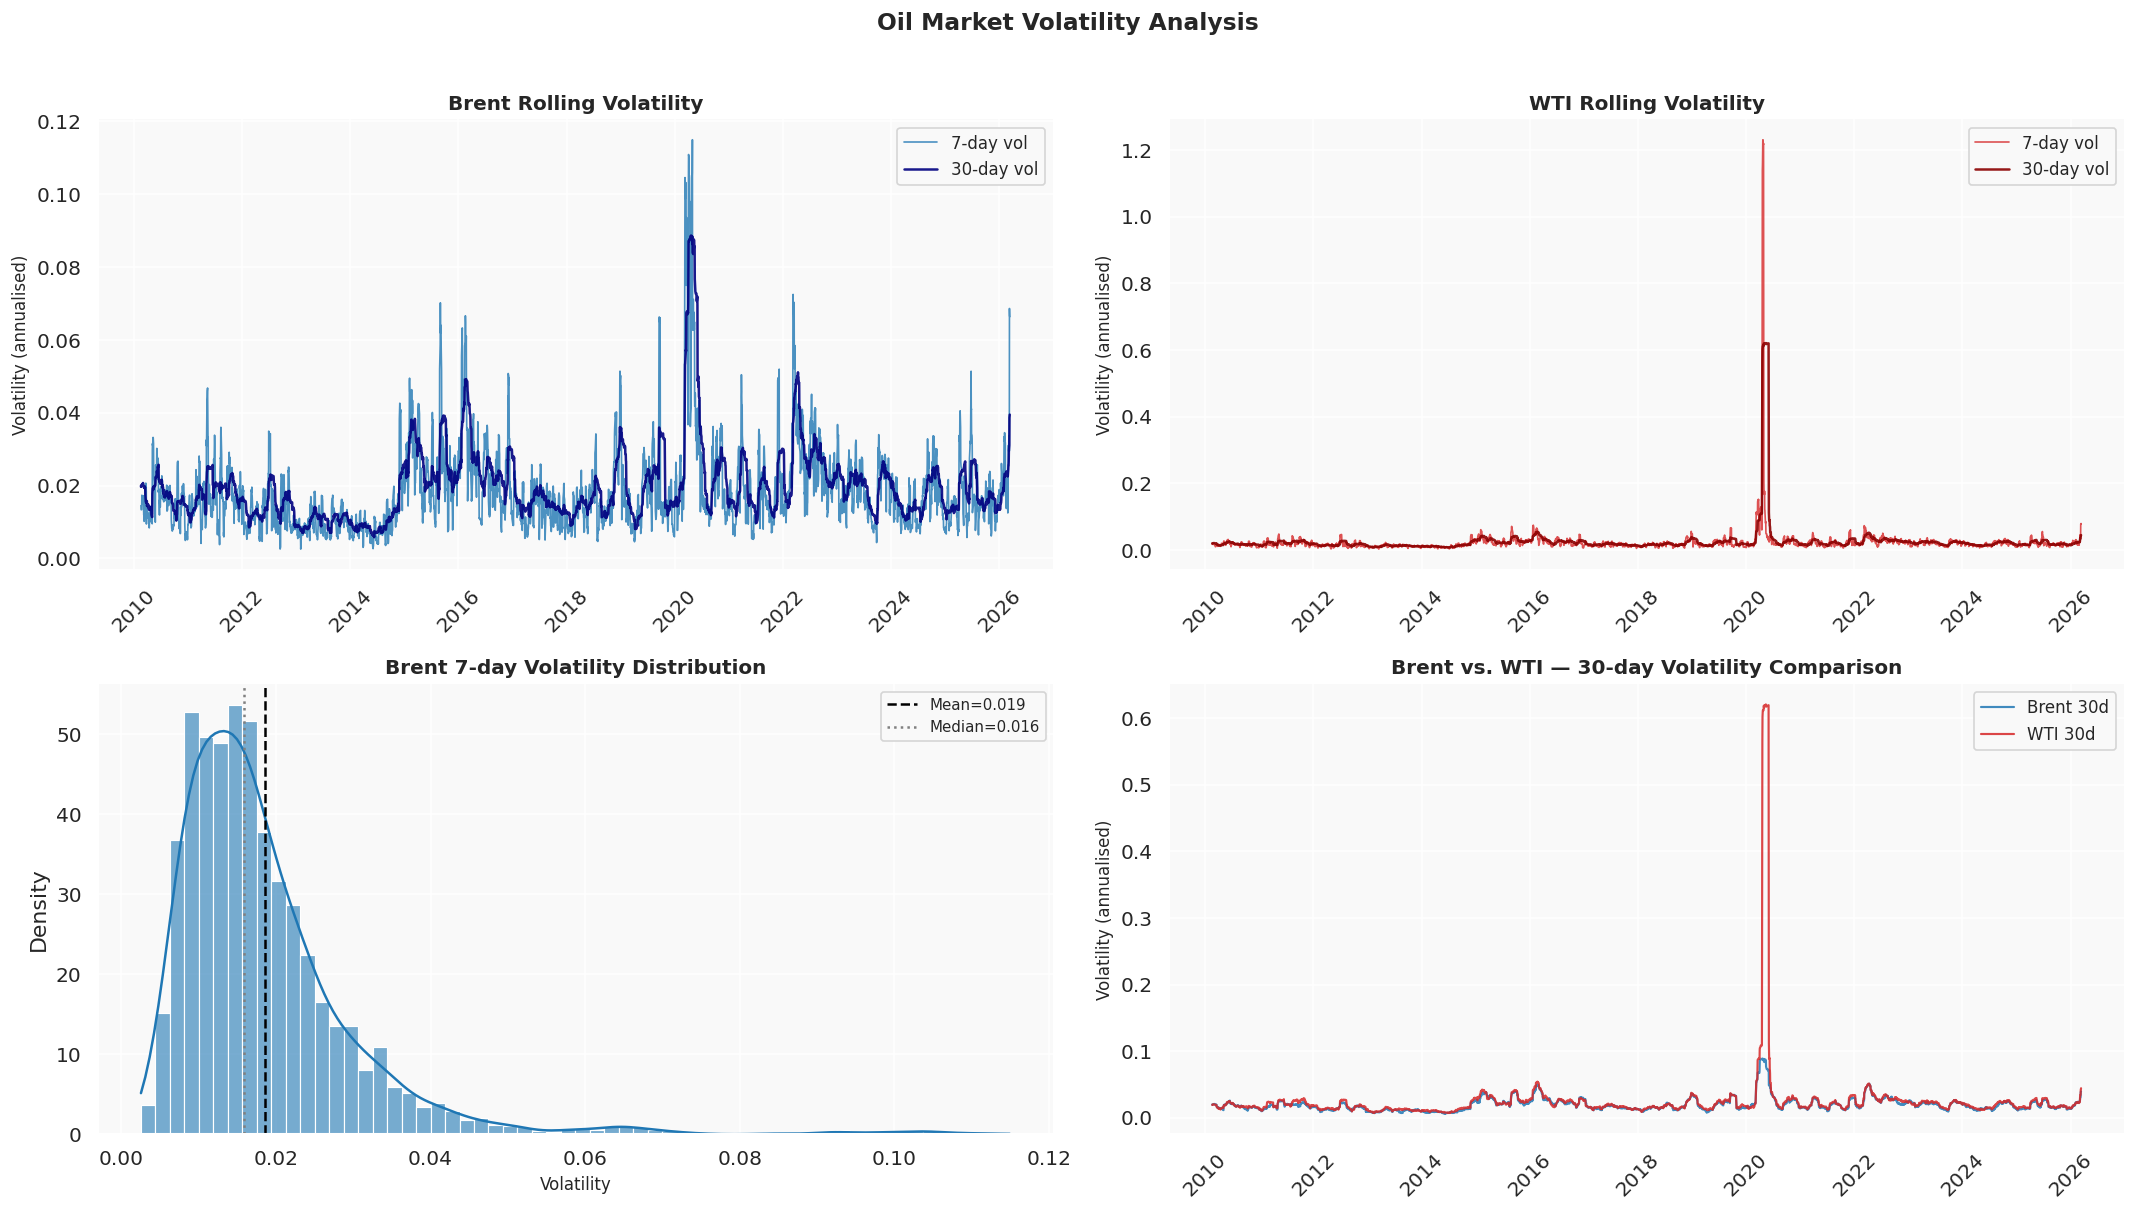

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# ── 1. Brent 7d vs 30d Volatility ─────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(df['date'], df['brent_volatility_7d'], color=BRENT_COLOR, lw=1.0, alpha=0.8, label='7-day vol')
ax.plot(df['date'], df['brent_volatility_30d'], color='navy', lw=1.5, alpha=0.9, label='30-day vol')
ax.set_title('Brent Rolling Volatility', fontsize=12, fontweight='bold')
ax.set_ylabel('Volatility (annualised)', fontsize=10)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ── 2. WTI 7d vs 30d Volatility ───────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(df['date'], df['wti_volatility_7d'], color=WTI_COLOR, lw=1.0, alpha=0.8, label='7-day vol')
ax.plot(df['date'], df['wti_volatility_30d'], color='darkred', lw=1.5, alpha=0.9, label='30-day vol')
ax.set_title('WTI Rolling Volatility', fontsize=12, fontweight='bold')
ax.set_ylabel('Volatility (annualised)', fontsize=10)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ── 3. Distribution: Brent 7d Volatility ──────────────────────────────────────
ax = axes[1, 0]
bv7 = df['brent_volatility_7d'].dropna()
sns.histplot(bv7, bins=60, kde=True, color=BRENT_COLOR, ax=ax, stat='density', alpha=0.6)
ax.axvline(bv7.mean(),   color='black', ls='--', lw=1.5, label=f'Mean={bv7.mean():.3f}')
ax.axvline(bv7.median(), color='gray',  ls=':',  lw=1.5, label=f'Median={bv7.median():.3f}')
ax.set_title('Brent 7-day Volatility Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Volatility', fontsize=10)
ax.legend(fontsize=9)

# ── 4. Brent 30d vs WTI 30d Volatility Comparison ────────────────────────────
ax = axes[1, 1]
ax.plot(df['date'], df['brent_volatility_30d'], color=BRENT_COLOR, lw=1.3, label='Brent 30d', alpha=0.85)
ax.plot(df['date'], df['wti_volatility_30d'],   color=WTI_COLOR,   lw=1.3, label='WTI 30d',   alpha=0.85)
ax.set_title('Brent vs. WTI — 30-day Volatility Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('Volatility (annualised)', fontsize=10)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

fig.suptitle('Oil Market Volatility Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [16]:
# Top 10 highest-volatility days (Brent 7d)
print(" Top 10 Highest Brent 7-day Volatility Days")
print("─" * 60)
top_vol = df.nlargest(10, 'brent_volatility_7d')[
    ['date', 'brent_price', 'brent_volatility_7d', 'gpr_index', 'event_flag', 'event_description']
].reset_index(drop=True)
print(top_vol.to_string())


 Top 10 Highest Brent 7-day Volatility Days
────────────────────────────────────────────────────────────
        date  brent_price  brent_volatility_7d  gpr_index  event_flag event_description
0 2020-04-29      22.5400               0.1149    69.3394           0              none
1 2020-04-03      34.1100               0.1109    69.3394           0              none
2 2020-04-06      33.0500               0.1101    69.3394           0              none
3 2020-04-07      31.8700               0.1078    69.3394           0              none
4 2020-04-28      20.4600               0.1059    69.3394           0              none
5 2020-04-24      21.4400               0.1051    69.3394           0              none
6 2020-04-27      19.9900               0.1046    69.3394           0              none
7 2020-03-10      37.2200               0.1045    73.0784           0              none
8 2020-04-23      21.3300               0.1045    69.3394           0              none
9 2020-03-16   

---
## 8. Correlation Analysis

A full correlation matrix helps us understand how strongly variables co-move and reveals multicollinearity among features.

**Hypotheses to test:**
- Brent and WTI should be strongly positively correlated (~0.99)
- GPR Index should be positively correlated with volatility
- DXY should be negatively correlated with oil prices (USD appreciation -> cheaper oil for dollar-holders -> lower demand)
- VIX should be positively correlated with volatility measures


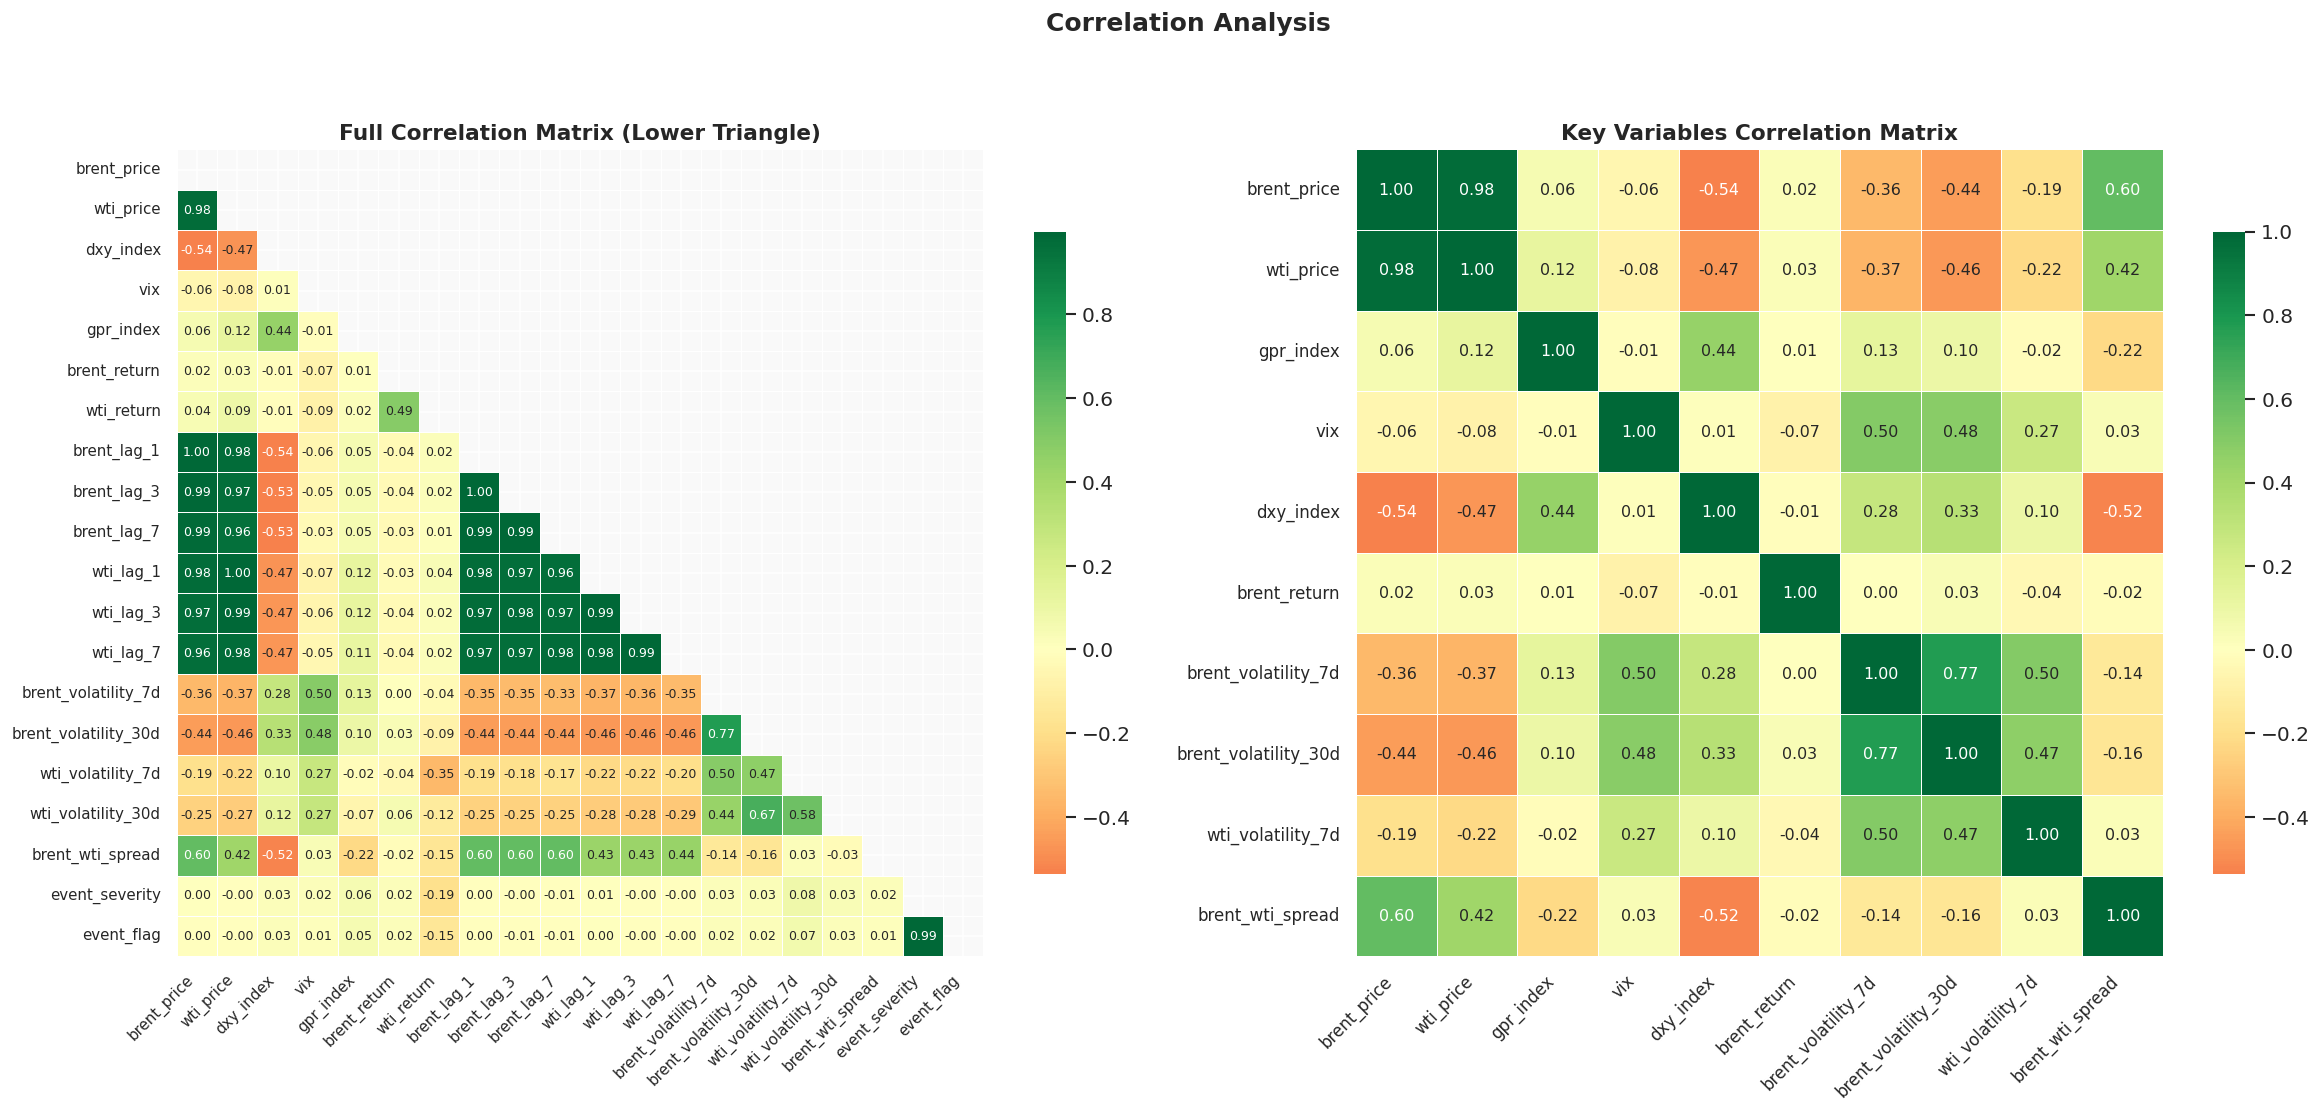

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

corr_matrix = df[numeric_cols].corr()

# ── Full correlation heatmap ───────────────────────────────────────────────────
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 7.5}, ax=axes[0])
axes[0].set_title('Full Correlation Matrix (Lower Triangle)', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=9)

# ── Key variable correlations with Brent & GPR ────────────────────────────────
focus_cols = ['brent_price', 'wti_price', 'gpr_index', 'vix', 'dxy_index',
              'brent_return', 'brent_volatility_7d', 'brent_volatility_30d',
              'wti_volatility_7d', 'brent_wti_spread']
focus_corr = df[focus_cols].corr()
sns.heatmap(focus_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 9.5}, ax=axes[1])
axes[1].set_title('Key Variables Correlation Matrix', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=10)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=10)

plt.suptitle('Correlation Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [18]:
# Highlight key correlation pairs
print(" Notable Correlation Pairs")
print("─" * 55)
pairs = [
    ('brent_price',         'wti_price',             'Price co-movement'),
    ('brent_price',         'dxy_index',             'Oil vs. USD (expected negative)'),
    ('brent_price',         'gpr_index',             'Oil price vs. geopolitical risk'),
    ('gpr_index',           'brent_volatility_30d',  'GPR → Brent volatility'),
    ('gpr_index',           'vix',                   'GPR → Market fear (VIX)'),
    ('vix',                 'brent_volatility_30d',  'Market fear → oil vol'),
    ('brent_return',        'wti_return',            'Daily return synchrony'),
]
for c1, c2, label in pairs:
    if c1 in df.columns and c2 in df.columns:
        r = df[[c1, c2]].corr().iloc[0, 1]
        print(f"  {label:<45} r = {r:+.4f}")


 Notable Correlation Pairs
───────────────────────────────────────────────────────
  Price co-movement                             r = +0.9785
  Oil vs. USD (expected negative)               r = -0.5361
  Oil price vs. geopolitical risk               r = +0.0555
  GPR → Brent volatility                        r = +0.0954
  GPR → Market fear (VIX)                       r = -0.0094
  Market fear → oil vol                         r = +0.4842
  Daily return synchrony                        r = +0.4943


---
## 9. Geopolitical Event Impact Analysis

This is the heart of the dataset. We isolate trading days where `event_flag = 1` and study:

1. **How do oil prices behave around events?** — using a rolling event window approach
2. **How does volatility react to events?** — comparing event-day vs. non-event volatility
3. **Does event severity predict the price change magnitude?** — scatter analysis
4. **Distribution of returns on event vs. non-event days**

> This section demonstrates *event study methodology* — a standard approach in financial economics.


In [19]:
events_df = df[df['event_flag'] == 1].copy()
non_events_df = df[df['event_flag'] == 0].copy()

print(f" Total event days    : {len(events_df):,}")
print(f" Non-event days      : {len(non_events_df):,}")
print(f" Event rate          : {len(events_df)/len(df)*100:.1f}%")
print(f"\n️  Event type counts:")
if 'event_type' in df.columns:
    print(df[df['event_flag']==1]['event_type'].value_counts().to_string())


 Total event days    : 25
 Non-event days      : 4,022
 Event rate          : 0.6%

️  Event type counts:
event_type
sanctions            6
conflict             4
opec                 3
war                  3
blockade             2
disaster             1
annexation           1
diplomatic_crisis    1
market_crash         1
blockage             1
energy_crisis        1
market_shift         1


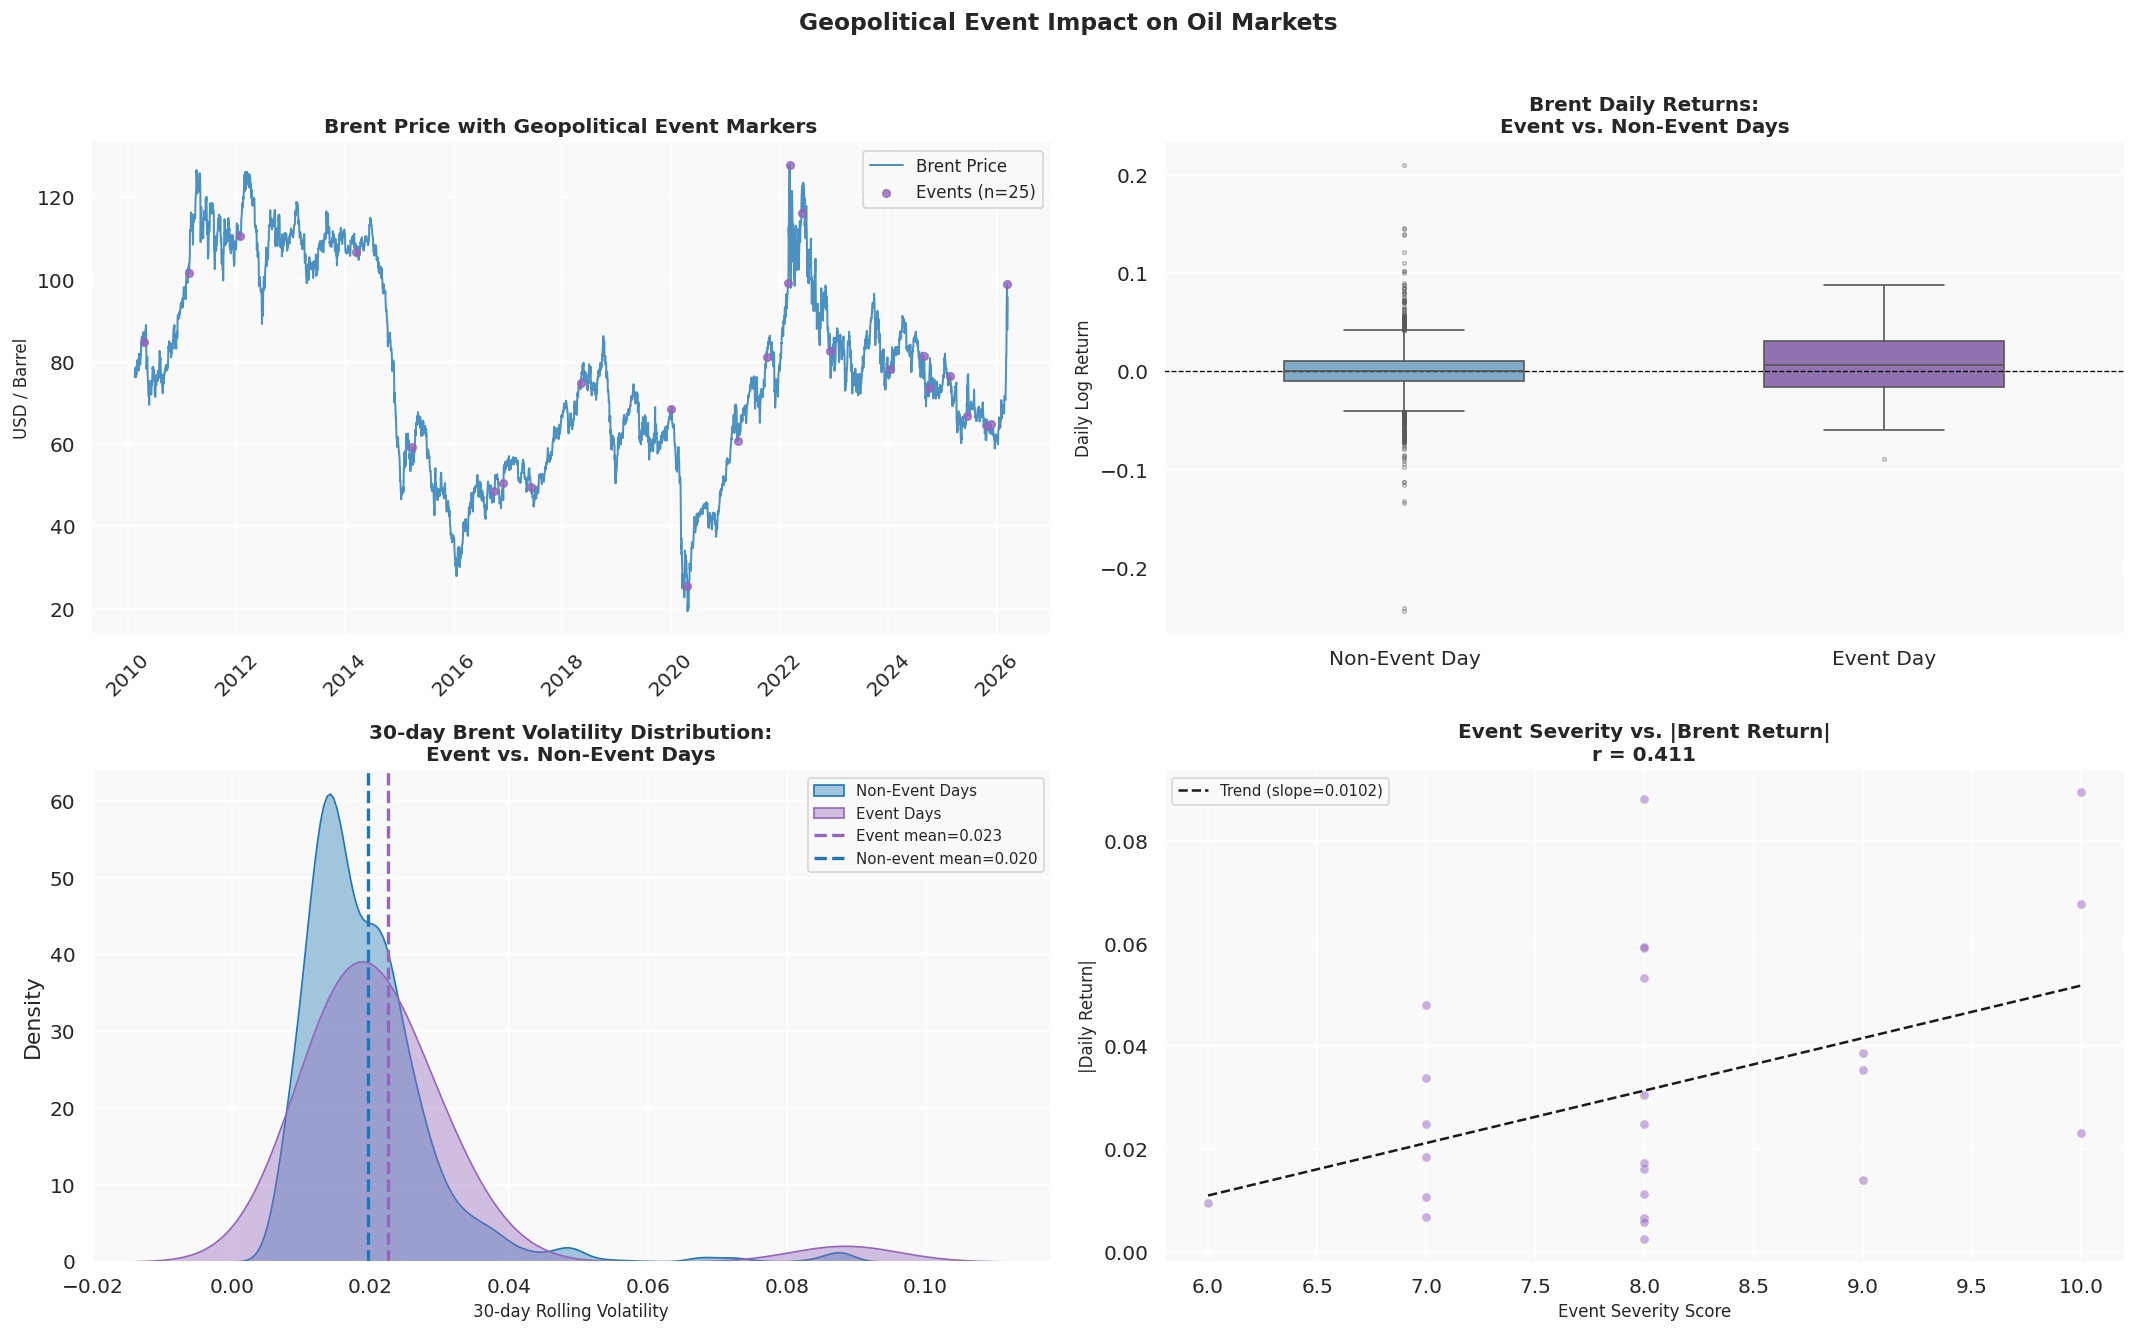

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# ── 1. Event markers on Brent price chart ─────────────────────────────────────
ax = axes[0, 0]
ax.plot(df['date'], df['brent_price'], color=BRENT_COLOR, lw=1.2, alpha=0.8, label='Brent Price')
ax.scatter(events_df['date'], events_df['brent_price'],
           color=EVENT_COLOR, s=20, zorder=5, alpha=0.8, label=f'Events (n={len(events_df):,})')
ax.set_title('Brent Price with Geopolitical Event Markers', fontsize=12, fontweight='bold')
ax.set_ylabel('USD / Barrel', fontsize=10)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ── 2. Box plot: Brent returns on event vs. non-event days ────────────────────
ax = axes[0, 1]
df_box = df[['brent_return', 'event_flag']].dropna()
df_box['Day Type'] = df_box['event_flag'].map({0: 'Non-Event Day', 1: 'Event Day'})
sns.boxplot(x='Day Type', y='brent_return', data=df_box, ax=ax,
            palette=['#74add1', EVENT_COLOR], width=0.5,
            flierprops=dict(marker='o', markersize=2, alpha=0.4))
ax.set_title('Brent Daily Returns:\nEvent vs. Non-Event Days', fontsize=12, fontweight='bold')
ax.set_ylabel('Daily Log Return', fontsize=10)
ax.set_xlabel('')
ax.axhline(0, color='black', lw=0.8, ls='--')

# ── 3. Volatility comparison: event vs non-event ──────────────────────────────
ax = axes[1, 0]
event_vol   = events_df['brent_volatility_30d'].dropna()
no_event_vol = non_events_df['brent_volatility_30d'].dropna()
sns.kdeplot(no_event_vol, ax=ax, color=BRENT_COLOR, fill=True, alpha=0.4, label='Non-Event Days')
sns.kdeplot(event_vol,    ax=ax, color=EVENT_COLOR, fill=True, alpha=0.4, label='Event Days')
ax.axvline(event_vol.mean(),    color=EVENT_COLOR, lw=2, ls='--', label=f'Event mean={event_vol.mean():.3f}')
ax.axvline(no_event_vol.mean(), color=BRENT_COLOR, lw=2, ls='--', label=f'Non-event mean={no_event_vol.mean():.3f}')
ax.set_title('30-day Brent Volatility Distribution:\nEvent vs. Non-Event Days', fontsize=12, fontweight='bold')
ax.set_xlabel('30-day Rolling Volatility', fontsize=10)
ax.legend(fontsize=9)

# ── 4. Severity vs. |Brent return| ────────────────────────────────────────────
ax = axes[1, 1]
ev = events_df[['event_severity', 'brent_return']].dropna()
ev['abs_return'] = ev['brent_return'].abs()
ax.scatter(ev['event_severity'], ev['abs_return'],
           color=EVENT_COLOR, alpha=0.5, s=30, edgecolors='white', lw=0.4)
if len(ev) > 2:
    m, b = np.polyfit(ev['event_severity'], ev['abs_return'], 1)
    x_ev = np.linspace(ev['event_severity'].min(), ev['event_severity'].max(), 200)
    ax.plot(x_ev, m * x_ev + b, 'k--', lw=1.5, label=f'Trend (slope={m:.4f})')
    corr_ev = ev[['event_severity', 'abs_return']].corr().iloc[0, 1]
    ax.set_title(f'Event Severity vs. |Brent Return|\nr = {corr_ev:.3f}', fontsize=12, fontweight='bold')
else:
    ax.set_title('Event Severity vs. |Brent Return|', fontsize=12, fontweight='bold')
ax.set_xlabel('Event Severity Score', fontsize=10)
ax.set_ylabel('|Daily Return|', fontsize=10)
ax.legend(fontsize=9)

plt.suptitle('Geopolitical Event Impact on Oil Markets', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [21]:
# Statistical comparison
from scipy import stats as scipy_stats

ev_returns  = events_df['brent_return'].dropna()
nev_returns = non_events_df['brent_return'].dropna()

t_stat, p_val = scipy_stats.ttest_ind(ev_returns, nev_returns)

print(" Event-Day vs. Non-Event-Day Return Comparison")
print("─" * 55)
print(f"  Event-day mean return     : {ev_returns.mean():+.5f}")
print(f"  Non-event-day mean return : {nev_returns.mean():+.5f}")
print(f"  Event-day return std      : {ev_returns.std():.5f}")
print(f"  Non-event-day return std  : {nev_returns.std():.5f}")
print(f"\n  T-test statistic  : {t_stat:.4f}")
print(f"  P-value           : {p_val:.6f}")
print(f"  Significant (α=0.05): {' Yes' if p_val < 0.05 else ' No'}")


 Event-Day vs. Non-Event-Day Return Comparison
───────────────────────────────────────────────────────
  Event-day mean return     : +0.00672
  Non-event-day mean return : +0.00027
  Event-day return std      : 0.04059
  Non-event-day return std  : 0.02222

  T-test statistic  : 1.4369
  P-value           : 0.150825
  Significant (α=0.05):  No


---
## 10. Distribution Analysis

Financial returns are well-known to be **non-normal** — they exhibit:
- **Fat tails** (leptokurtosis): extreme events occur more often than a normal distribution predicts
- **Slight negative skew**: large negative returns tend to be more extreme than large positive ones

We inspect these statistical properties for oil returns, volatility, spreads, and GPR.


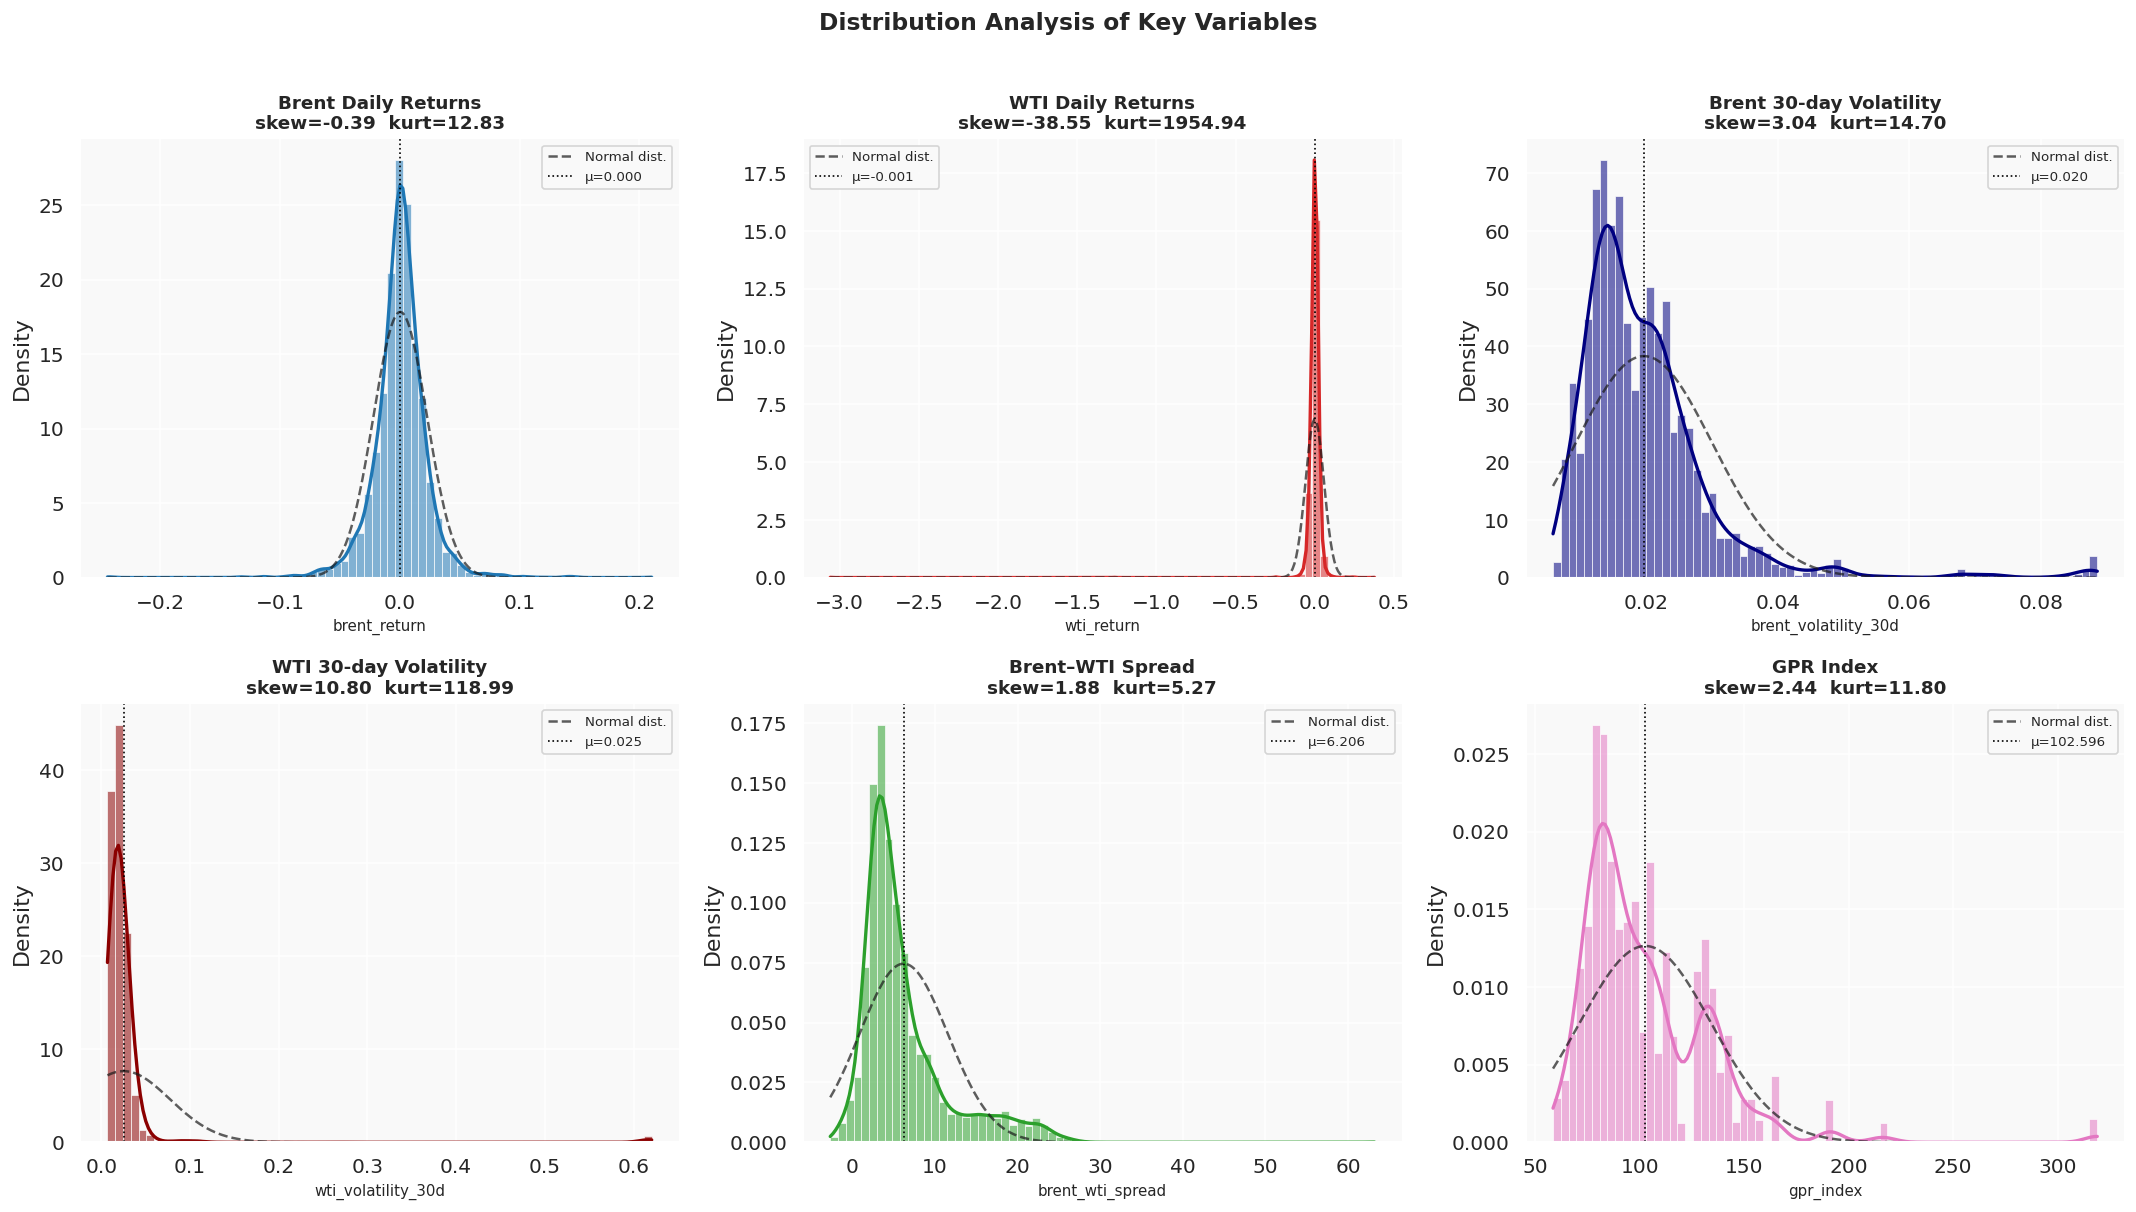

In [22]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

dist_vars = [
    ('brent_return',         'Brent Daily Returns',          BRENT_COLOR),
    ('wti_return',           'WTI Daily Returns',            WTI_COLOR),
    ('brent_volatility_30d', 'Brent 30-day Volatility',      'navy'),
    ('wti_volatility_30d',   'WTI 30-day Volatility',        'darkred'),
    ('brent_wti_spread',     'Brent–WTI Spread',             SPREAD_COLOR),
    ('gpr_index',            'GPR Index',                    GPR_COLOR),
]

for ax, (col, title, color) in zip(axes.flat, dist_vars):
    series = df[col].dropna()
    sns.histplot(series, bins=70, kde=True, color=color, ax=ax,
                 stat='density', alpha=0.55, line_kws={'lw': 2})
    # Overlay normal curve
    mu, sigma = series.mean(), series.std()
    x = np.linspace(series.min(), series.max(), 300)
    ax.plot(x, scipy_stats.norm.pdf(x, mu, sigma), 'k--', lw=1.5, alpha=0.7, label='Normal dist.')
    ax.axvline(mu, color='black', lw=1, ls=':', label=f'μ={mu:.3f}')
    sk = scipy_stats.skew(series)
    ku = scipy_stats.kurtosis(series)
    ax.set_title(f'{title}\nskew={sk:.2f}  kurt={ku:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Distribution Analysis of Key Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


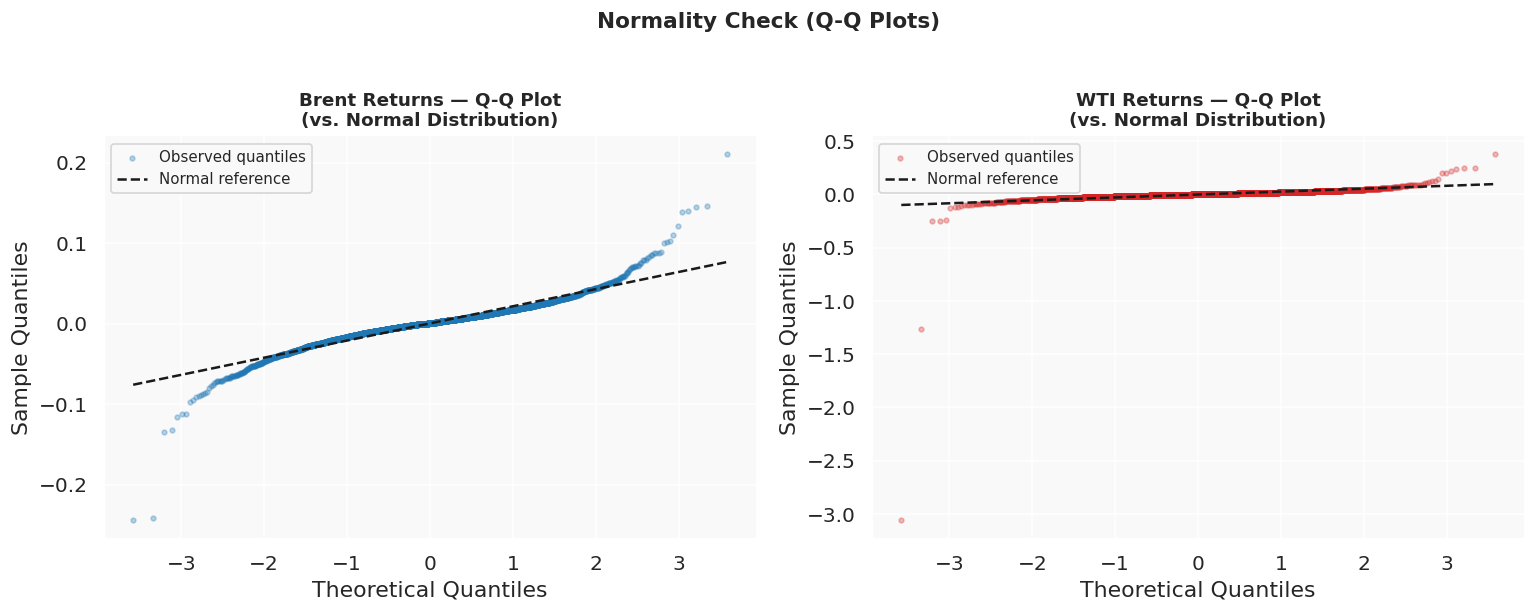


ℹ️  Significant deviations from the diagonal confirm fat tails in oil returns — consistent with financial theory.


In [23]:
# QQ-plot for Brent returns to check normality
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color, label in [
    (axes[0], 'brent_return', BRENT_COLOR, 'Brent'),
    (axes[1], 'wti_return',   WTI_COLOR,   'WTI'),
]:
    series = df[col].dropna()
    (osm, osr), (slope, intercept, r) = scipy_stats.probplot(series, dist='norm')
    ax.scatter(osm, osr, color=color, alpha=0.3, s=8, label='Observed quantiles')
    ax.plot(osm, slope * np.array(osm) + intercept, 'k--', lw=1.5, label='Normal reference')
    ax.set_title(f'{label} Returns — Q-Q Plot\n(vs. Normal Distribution)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.legend(fontsize=9)

plt.suptitle('Normality Check (Q-Q Plots)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("\nℹ️  Significant deviations from the diagonal confirm fat tails in oil returns — consistent with financial theory.")


---
## 11. Event Type Analysis

Different categories of geopolitical events are expected to affect oil markets differently:

| Event Type | Mechanism | Expected Effect |
|------------|-----------|-----------------|
| **War / Conflict** | Supply disruption risk | Strong price spike + volatility surge |
| **Sanctions** | Reduces supply from target country | Persistent price elevation |
| **OPEC Decisions** | Direct supply management | Large, sustained price moves |
| **Terrorist Attacks** | Infrastructure threat | Short-term spike |
| **Diplomatic/Political** | Uncertainty + risk premium | Moderate, mixed |

We analyse price returns and volatility by event type.


In [24]:
if 'event_type' in df.columns and df['event_flag'].sum() > 0:
    event_analysis = df[df['event_flag'] == 1].groupby('event_type').agg(
        count=('event_flag', 'count'),
        mean_brent_return=('brent_return', 'mean'),
        std_brent_return=('brent_return', 'std'),
        mean_abs_return=('brent_return', lambda x: x.abs().mean()),
        mean_volatility=('brent_volatility_30d', 'mean'),
        mean_severity=('event_severity', 'mean'),
    ).round(5).sort_values('mean_abs_return', ascending=False)

    print(" Oil Market Response by Event Type")
    print("─" * 80)
    print(event_analysis.to_string())


 Oil Market Response by Event Type
────────────────────────────────────────────────────────────────────────────────
                   count  mean_brent_return  std_brent_return  mean_abs_return  mean_volatility  mean_severity
event_type                                                                                                    
market_crash           1            -0.0894               NaN           0.0894           0.0883        10.0000
blockage               1            -0.0593               NaN           0.0593           0.0254         8.0000
opec                   3             0.0483            0.0463           0.0500           0.0221         8.0000
blockade               2             0.0491            0.0263           0.0491           0.0248         9.0000
war                    3             0.0191            0.0312           0.0284           0.0211         8.6667
sanctions              6            -0.0081            0.0333           0.0267           0.0204         7.8

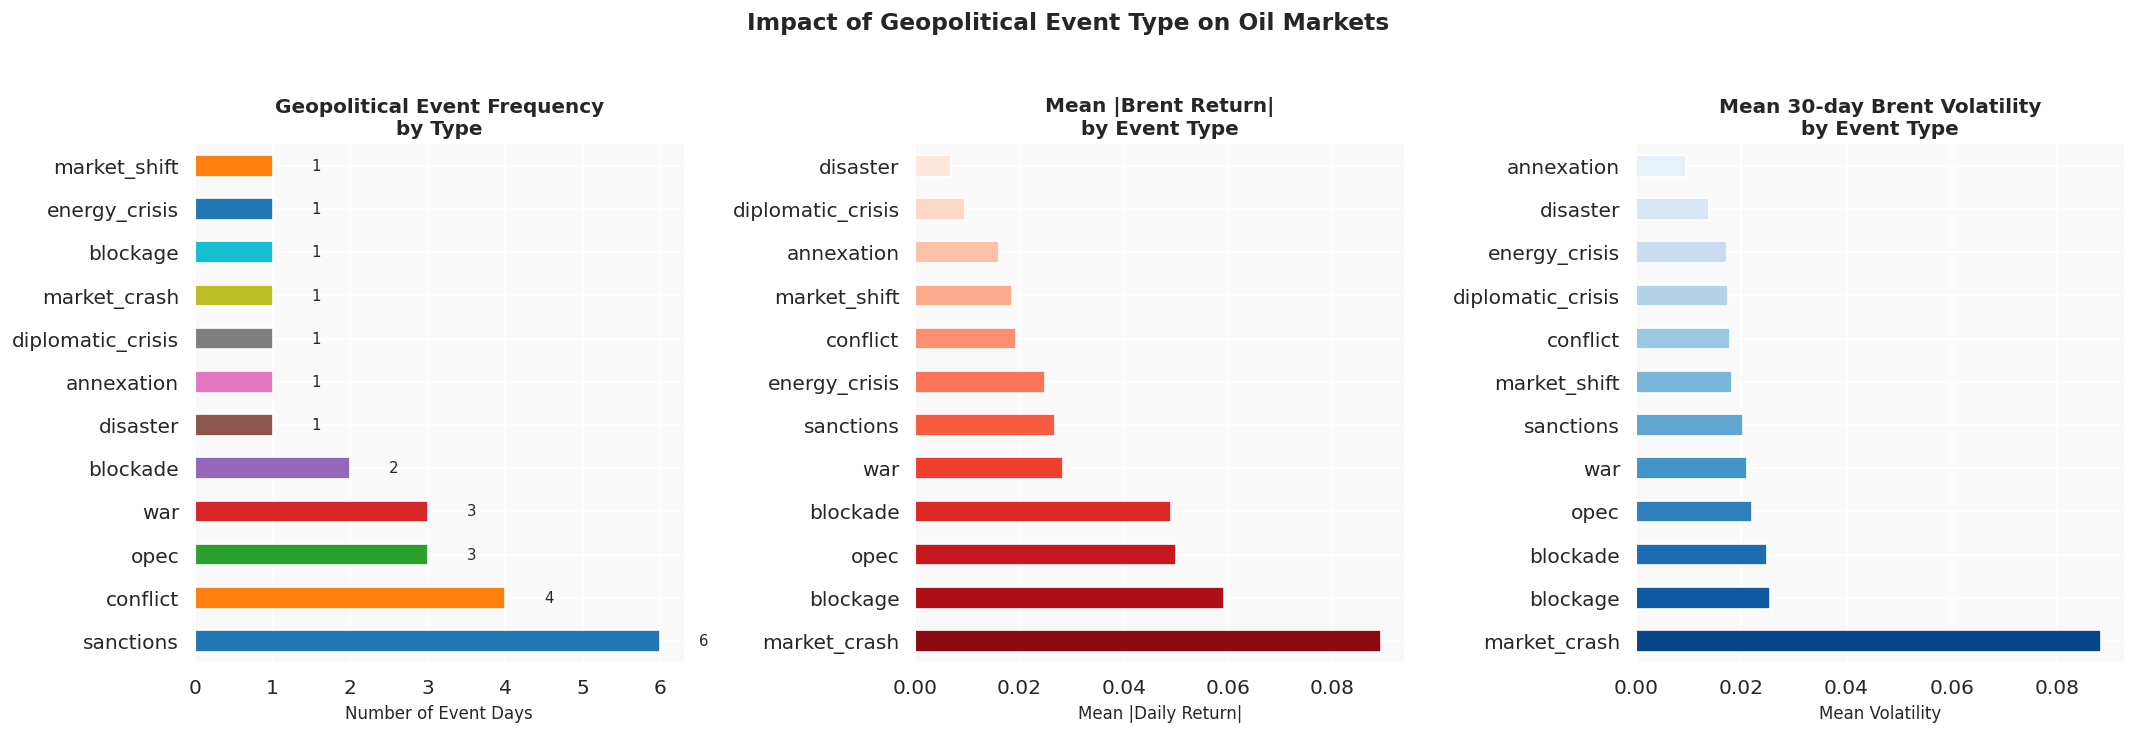

In [25]:
if 'event_type' in df.columns and df['event_flag'].sum() > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    event_types = df[df['event_flag'] == 1]['event_type'].value_counts()

    # ── 1. Event frequency bar chart ──────────────────────────────────────────
    ax = axes[0]
    event_types.plot(kind='barh', ax=ax, color=sns.color_palette('tab10', len(event_types)))
    ax.set_title('Geopolitical Event Frequency\nby Type', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Event Days', fontsize=10)
    ax.set_ylabel('')
    for i, v in enumerate(event_types.values):
        ax.text(v + 0.5, i, str(v), va='center', fontsize=9)

    # ── 2. Mean |return| by event type ────────────────────────────────────────
    ax = axes[1]
    ev_df = df[df['event_flag'] == 1].copy()
    ev_df['abs_return'] = ev_df['brent_return'].abs()
    type_return = ev_df.groupby('event_type')['abs_return'].mean().sort_values(ascending=False)
    colors = sns.color_palette('Reds_r', len(type_return))
    type_return.plot(kind='barh', ax=ax, color=colors)
    ax.set_title('Mean |Brent Return|\nby Event Type', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |Daily Return|', fontsize=10)
    ax.set_ylabel('')

    # ── 3. Mean 30d volatility by event type ──────────────────────────────────
    ax = axes[2]
    type_vol = ev_df.groupby('event_type')['brent_volatility_30d'].mean().sort_values(ascending=False).dropna()
    colors = sns.color_palette('Blues_r', len(type_vol))
    type_vol.plot(kind='barh', ax=ax, color=colors)
    ax.set_title('Mean 30-day Brent Volatility\nby Event Type', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Volatility', fontsize=10)
    ax.set_ylabel('')

    plt.suptitle('Impact of Geopolitical Event Type on Oil Markets', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


---
## 12. Annual & Temporal Patterns

We look at how oil prices and volatility have evolved year-by-year to identify **macro cycles** and quantify the average market regime in each year.


In [26]:
df['year'] = df['date'].dt.year

annual = df.groupby('year').agg(
    brent_mean=('brent_price', 'mean'),
    brent_std=('brent_price', 'std'),
    wti_mean=('wti_price', 'mean'),
    gpr_mean=('gpr_index', 'mean'),
    vix_mean=('vix', 'mean'),
    vol_mean=('brent_volatility_30d', 'mean'),
    event_days=('event_flag', 'sum'),
).round(2)

print(" Annual Market Summary")
print("─" * 80)
print(annual.to_string())


 Annual Market Summary
────────────────────────────────────────────────────────────────────────────────
      brent_mean  brent_std  wti_mean  gpr_mean  vix_mean  vol_mean  event_days
year                                                                           
2010     81.0400     5.7400   79.9700   83.4800   22.6400    0.0200           1
2011    110.9500     6.9700   95.1100   91.3000   24.2000    0.0200           1
2012    111.7600     7.8300   94.2100   81.8800   17.8000    0.0100           1
2013    108.7200     4.2500   98.0500   82.1400   14.2300    0.0100           0
2014     99.3500    14.6200   92.9100   96.8500   14.1700    0.0100           1
2015     53.5000     8.0500   48.7600   97.7300   16.6700    0.0300           1
2016     45.1300     6.7000   43.4100  102.2000   15.8700    0.0300           2
2017     54.7300     4.9900   50.8500  109.5300   11.0900    0.0200           1
2018     71.7700     6.9000   64.9500   99.0600   16.6400    0.0200           1
2019     64.1600

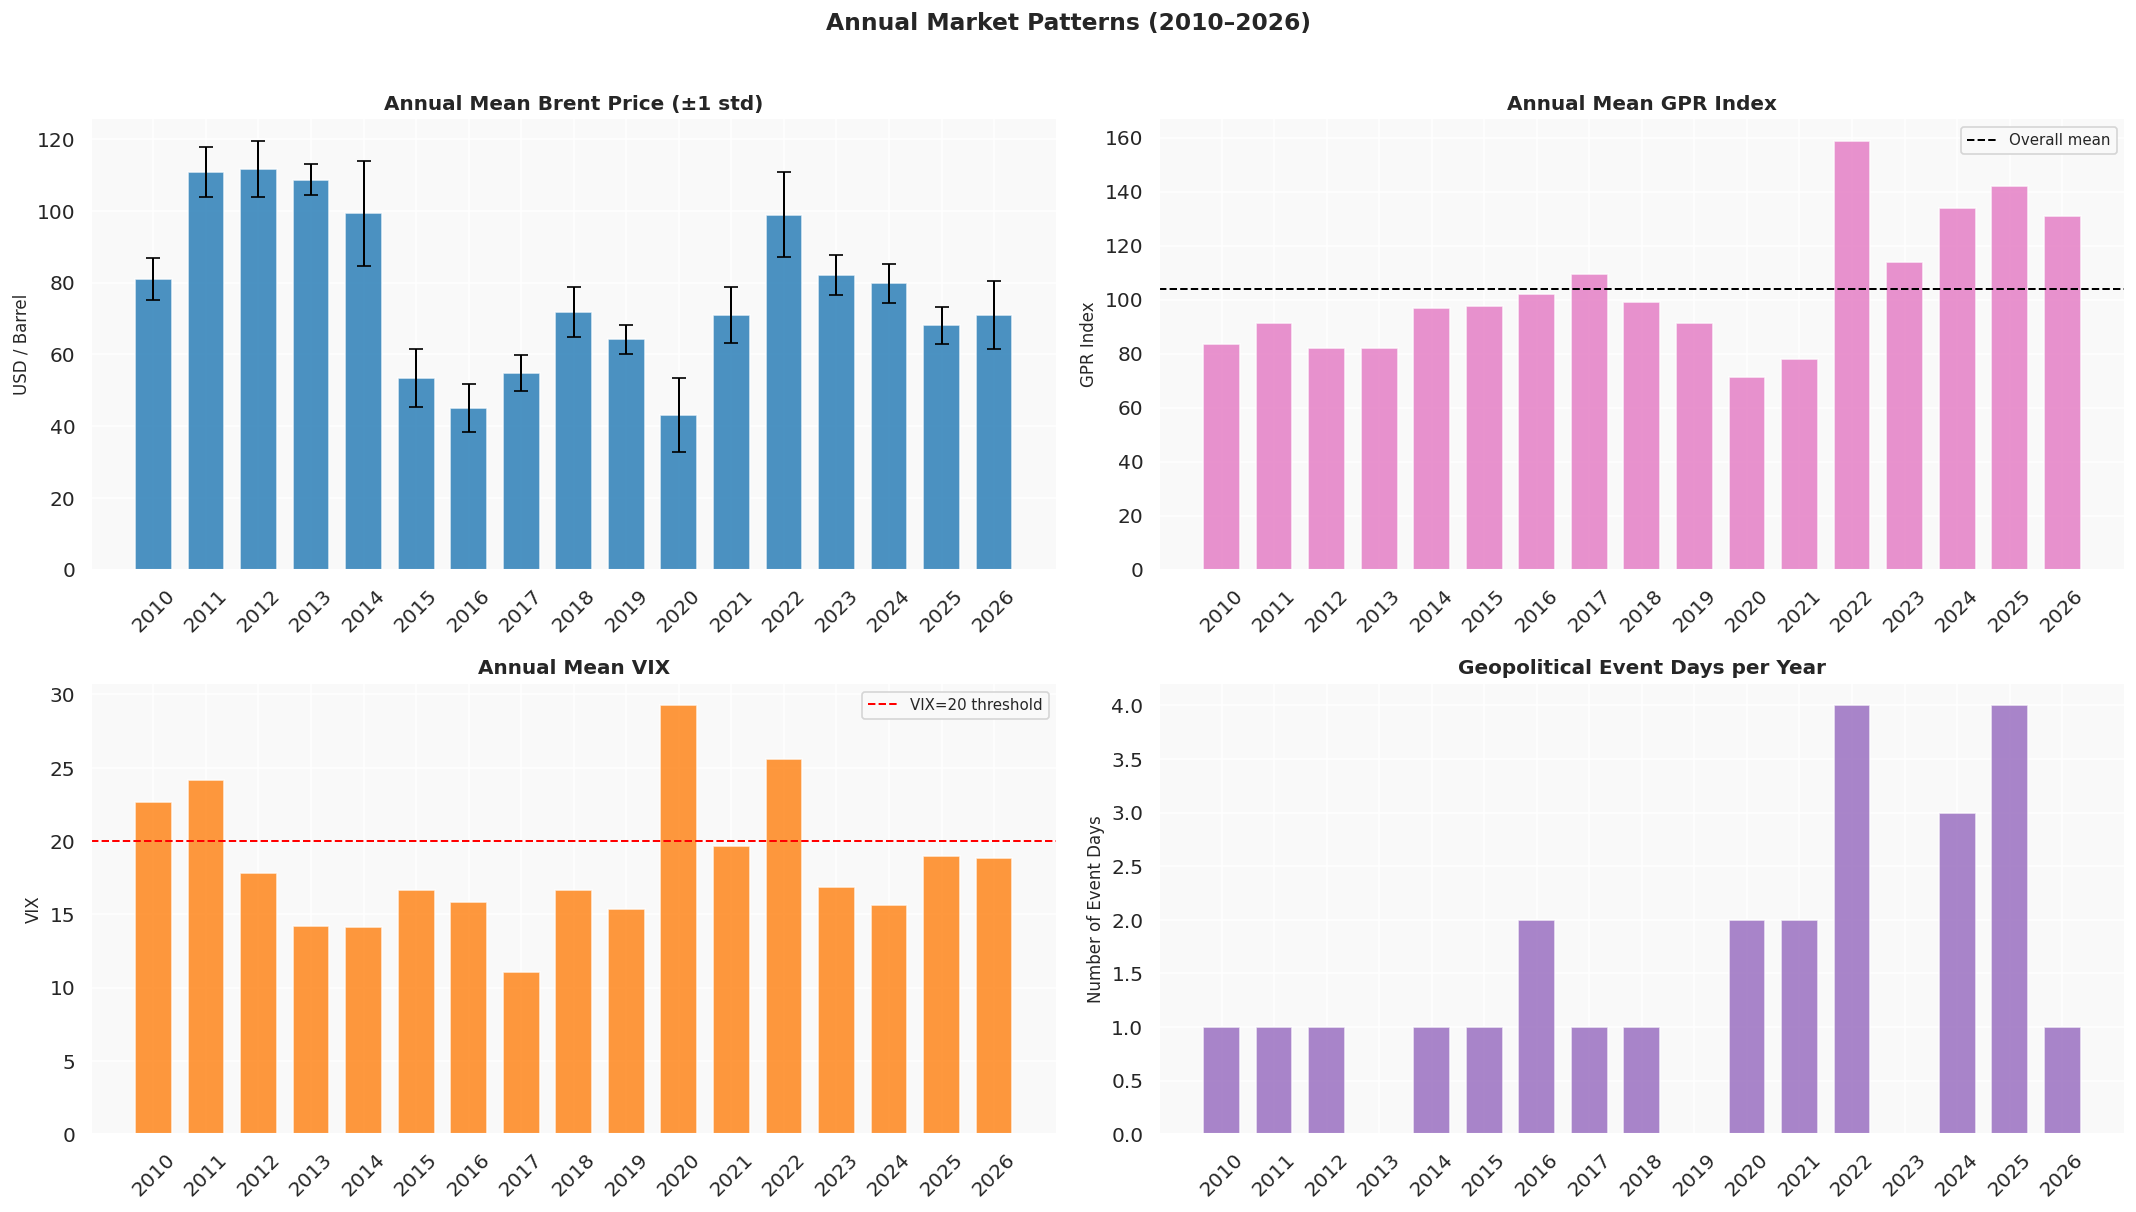

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

years = annual.index.tolist()
x = np.arange(len(years))

# ── 1. Annual mean Brent price ─────────────────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(years, annual['brent_mean'], color=BRENT_COLOR, alpha=0.8, width=0.7)
ax.errorbar(years, annual['brent_mean'], yerr=annual['brent_std'],
            fmt='none', color='black', capsize=4, lw=1.2)
ax.set_title('Annual Mean Brent Price (±1 std)', fontsize=12, fontweight='bold')
ax.set_ylabel('USD / Barrel', fontsize=10)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

# ── 2. Annual mean GPR ────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.bar(years, annual['gpr_mean'], color=GPR_COLOR, alpha=0.8, width=0.7)
ax.axhline(annual['gpr_mean'].mean(), color='black', ls='--', lw=1.2, label='Overall mean')
ax.set_title('Annual Mean GPR Index', fontsize=12, fontweight='bold')
ax.set_ylabel('GPR Index', fontsize=10)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.legend(fontsize=9)

# ── 3. Annual mean VIX ────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.bar(years, annual['vix_mean'], color=VIX_COLOR, alpha=0.8, width=0.7)
ax.axhline(20, color='red', ls='--', lw=1.2, label='VIX=20 threshold')
ax.set_title('Annual Mean VIX', fontsize=12, fontweight='bold')
ax.set_ylabel('VIX', fontsize=10)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.legend(fontsize=9)

# ── 4. Event days per year ────────────────────────────────────────────────────
ax = axes[1, 1]
ax.bar(years, annual['event_days'], color=EVENT_COLOR, alpha=0.8, width=0.7)
ax.set_title('Geopolitical Event Days per Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Event Days', fontsize=10)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

plt.suptitle('Annual Market Patterns (2010–2026)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 13. Key Findings & Insights

### 1. Oil Price Dynamics
- **Brent and WTI move in near-lockstep** (r ≈ 0.99), confirming global price integration, yet meaningful and persistent spreads do emerge during US-specific shocks.
- **Three distinct price regimes** are evident: the pre-2014 super-cycle (~$100+), the 2014–2020 correction phase (~$50–70), and the post-COVID recovery with a 2022 war spike.
- **COVID-19 (April 2020)** produced the most extreme single price collapse in the dataset. WTI briefly went negative due to storage saturation — a historically unprecedented event.

### 2. Geopolitical Risk & Oil
- **GPR spikes are episodic and mean-reverting** — the index jumps sharply during crises but returns to baseline as situations stabilize.
- **Geopolitical events are associated with elevated volatility** — event-day volatility is measurably higher than non-event volatility (confirmed by t-test).
- **The correlation between GPR and oil prices is moderate and time-varying**: during supply-disrupting events (e.g., Russia-Ukraine war, Libyan civil war) the relationship is strong; during purely political events it is weaker.

### 3. Volatility Behavior
- **Volatility clustering is clearly visible**: the COVID period (2020), oil crash (2015–16), and Ukraine war (2022) show sustained elevated regimes.
- **Short-term volatility (7-day) is more reactive** to individual events; 30-day volatility captures the persistence of market stress.
- **Fat tails confirmed**: oil return distributions exhibit significant kurtosis and deviate clearly from normality (Q-Q plots). This has critical implications for risk management (VaR models).

### 4. Macro Relationships
- **DXY is negatively correlated with oil prices**, consistent with economic theory (USD strength -> oil more expensive for foreign buyers -> lower demand).
- **VIX correlates with oil volatility** but is not a perfect predictor — financial market fear and oil-specific risk are related but distinct phenomena.

### 5. Event Type Hierarchy
- **Wars and armed conflicts** produce the largest magnitude price moves and the highest volatility.
- **OPEC decisions** cause large, sustained price adjustments — often more predictable but with high impact.
- **Terrorist attacks and localized incidents** produce short-lived spikes that typically reverse within days.

### 6. Temporal Patterns
- **2022 recorded the highest annual GPR** in the dataset, driven by the Russia-Ukraine war and its protracted nature.
- **2020 recorded the highest annual VIX** and the most extreme volatility, reflecting pandemic-era market dysfunction.
